<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/seismic_to_rms_input_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From seismic acquisition to RMS-ready subsurface inputs

**A fully calculated and visual companion to the RMS → OPM Flow → ERT → NeqSim notebook**

This notebook follows the upstream half of the reservoir-model chain: a compact seismic
acquisition and stacking calculation, a real public processed SEG-Y volume, seismic and well
quality control, well ties, seeded horizon tracking, fault support, depth conversion,
uncertainty realizations, seismic attributes, and a validated package of files that RMS can
import.

The numerical workflow is executed from top to bottom. Tables and figures are retained in the
saved notebook. The public Reek test data are checksum-pinned; RMS itself is not bundled or run
in Colab because it is licensed commercial software.

## Learning outcomes and completion criteria

After running the notebook, you should be able to:

1. Explain why RMS normally receives processed/migrated seismic rather than raw shot records.
2. Calculate a synthetic common-midpoint gather, normal-moveout correction, and stack in Python.
3. Audit SEG-Y geometry, amplitudes, spatial coverage, wells, surfaces, and fault polygons.
4. Tie seismic event phase to well markers and track top/base horizons from sparse controls.
5. Quantify horizon error against a withheld public reference and create structural uncertainty
   realizations.
6. Calculate interval seismic attributes and test whether they genuinely predict well porosity.
7. Export SEG-Y, IRAP/RMS surfaces, RMS wells, LAS logs, polygons, tables, manifests, and an agent
   request.
8. Validate every exported object by reading it back independently with XTGeo, SEG-Y, and LAS
   readers.

Completion requires all named engineering assertions to pass, every code cell to execute, and
every figure to render without clipping or missing units.

## The full chain and the licensed boundary

The complete field workflow has two distinct handovers:

| Stage | Typical owner | Main evidence | Executed here? |
|---|---|---|---|
| Acquisition | Geophysics contractor | field records, navigation, observer logs | simplified CMP calculation |
| Processing | Processing geophysicist | conditioned gathers, velocities, migrated volumes | simplified NMO/stack calculation |
| Interpretation | Asset geophysicist | SEG-Y, ties, horizons, faults, uncertainty | yes, on public Reek data |
| RMS geomodelling | Geologist / petrophysicist | structural grid, facies and properties | licensed worker contract only |
| Reservoir simulation | Reservoir engineer | ROFF/GRDECL/ECLIPSE inputs and forecasts | next notebook |
| Uncertainty and facilities | Integrated team | ERT ensembles, OPM Flow, NeqSim | next notebook |

The executable public path therefore ends with **RMS-ready inputs plus a governed request**.
The licensed RMS worker is expected to build the geological grid and export ROFF files. The
companion notebook
[`rms_to_opm_flow_agent_ert.ipynb`](rms_to_opm_flow_agent_ert.ipynb) starts from those
RMS-origin exports and continues through OPM Flow, ERT, and NeqSim.

In [1]:
import importlib.metadata
import subprocess
import sys

REQUIRED_PACKAGES = {
    "lasio": "0.32",
    "segyio": "1.9.14",
    "xtgeo": "4.25.1",
}

installed_versions = {}
for package_name in REQUIRED_PACKAGES:
    try:
        installed_versions[package_name] = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        installed_versions[package_name] = None

requirements = [
    f"{name}=={required_version}"
    for name, required_version in REQUIRED_PACKAGES.items()
    if installed_versions[name] != required_version
]
if requirements:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *requirements],
        check=True,
        timeout=1200,
    )

print("Required subsurface packages:", REQUIRED_PACKAGES)

Required subsurface packages: {'lasio': '0.32', 'segyio': '1.9.14', 'xtgeo': '4.25.1'}


In [2]:
from importlib.metadata import version
from pathlib import Path
from urllib.request import urlretrieve
import hashlib
import json
import math
import os
import platform
import shutil
import time
import zipfile

import lasio
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
import scipy
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import PchipInterpolator, griddata
from scipy.ndimage import distance_transform_edt, gaussian_filter
from scipy.spatial import cKDTree
import segyio
import xtgeo
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "axes.titleweight": "bold",
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "figure.dpi": 110,
        "figure.facecolor": "white",
        "font.size": 9,
        "legend.frameon": False,
        "savefig.facecolor": "white",
    }
)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 100)

COLORS = {
    "input": "#D97706",
    "processed": "#2563EB",
    "reference": "#059669",
    "uncertainty": "#7C3AED",
    "rejected": "#DC2626",
    "neutral": "#475569",
}
RANDOM_SEED = 20260901
DATA_COMMIT = "cad17f24e22c19c6cefe6f647185395cc0a11add"
DATA_LICENSE = "LGPL-3.0"
DATA_ROOT = (
    "https://raw.githubusercontent.com/equinor/xtgeo-testdata/"
    f"{DATA_COMMIT}"
)
OUTPUT_DIRECTORY = Path("seismic_to_rms_outputs").resolve()
INPUT_DIRECTORY = OUTPUT_DIRECTORY / "public_input"
PACKAGE_DIRECTORY = OUTPUT_DIRECTORY / "rms_ready_package"
FIGURE_DIRECTORY = OUTPUT_DIRECTORY / "figures"
if OUTPUT_DIRECTORY.exists():
    shutil.rmtree(OUTPUT_DIRECTORY)
INPUT_DIRECTORY.mkdir(parents=True)
PACKAGE_DIRECTORY.mkdir(parents=True)
FIGURE_DIRECTORY.mkdir(parents=True)
FIGURE_PATHS = []


def save_figure(figure, filename):
    path = FIGURE_DIRECTORY / filename
    figure.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    FIGURE_PATHS.append(path)
    return path


runtime_table = pd.DataFrame(
    {
        "runtime": [
            "Python",
            "NumPy",
            "pandas",
            "SciPy",
            "Matplotlib",
            "XTGeo",
            "segyio",
            "lasio",
        ],
        "version": [
            platform.python_version(),
            version("numpy"),
            version("pandas"),
            version("scipy"),
            version("matplotlib"),
            version("xtgeo"),
            version("segyio"),
            version("lasio"),
        ],
    }
)
display(runtime_table)

,runtime,version
0,Python,3.12.13
1,NumPy,2.3.5
2,pandas,2.2.3
3,SciPy,1.17.0
4,Matplotlib,3.10.8
5,XTGeo,4.25.1
6,segyio,1.9.14
7,lasio,0.32


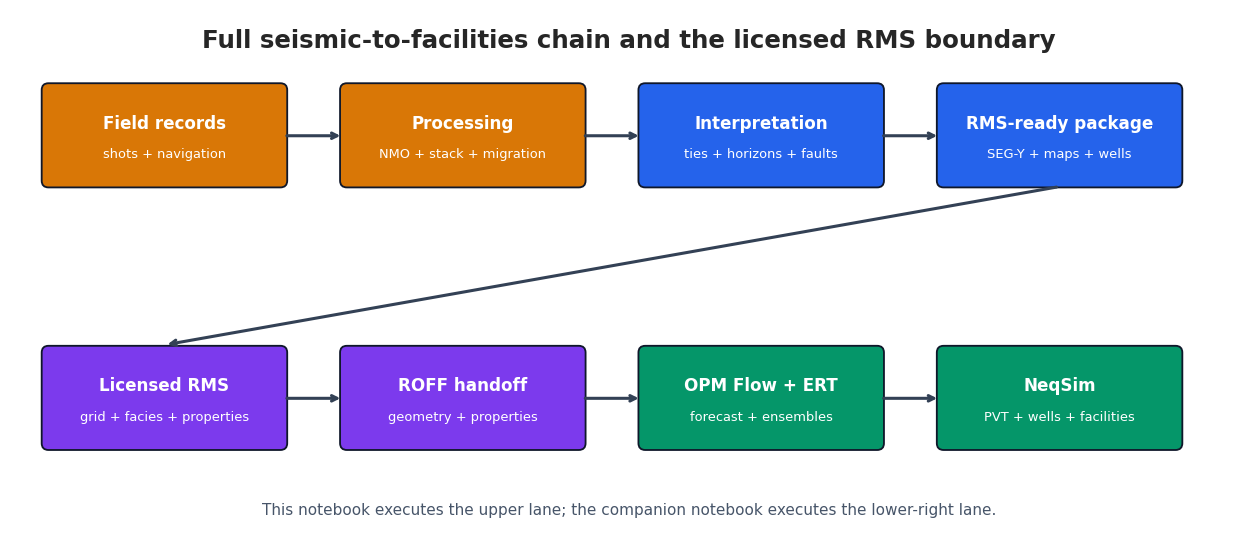

In [3]:
architecture_figure, architecture_axis = plt.subplots(figsize=(14.5, 6.3))
architecture_axis.set_xlim(0, 14.5)
architecture_axis.set_ylim(0, 6.3)
architecture_axis.axis("off")

nodes = [
    (0.4, 4.25, "Field records", "shots + navigation", COLORS["input"]),
    (3.9, 4.25, "Processing", "NMO + stack + migration", COLORS["input"]),
    (7.4, 4.25, "Interpretation", "ties + horizons + faults", COLORS["processed"]),
    (10.9, 4.25, "RMS-ready package", "SEG-Y + maps + wells", COLORS["processed"]),
    (0.4, 1.15, "Licensed RMS", "grid + facies + properties", COLORS["uncertainty"]),
    (3.9, 1.15, "ROFF handoff", "geometry + properties", COLORS["uncertainty"]),
    (7.4, 1.15, "OPM Flow + ERT", "forecast + ensembles", COLORS["reference"]),
    (10.9, 1.15, "NeqSim", "PVT + wells + facilities", COLORS["reference"]),
]
for x_value, y_value, title, subtitle, color in nodes:
    box = FancyBboxPatch(
        (x_value, y_value),
        2.8,
        1.15,
        boxstyle="round,pad=0.04,rounding_size=0.08",
        facecolor=color,
        edgecolor="#0F172A",
        linewidth=1.2,
    )
    architecture_axis.add_patch(box)
    architecture_axis.text(
        x_value + 1.4,
        y_value + 0.72,
        title,
        color="white",
        ha="center",
        va="center",
        fontsize=11,
        weight="bold",
    )
    architecture_axis.text(
        x_value + 1.4,
        y_value + 0.35,
        subtitle,
        color="white",
        ha="center",
        va="center",
        fontsize=8.5,
    )

arrow_pairs = [
    ((3.2, 4.82), (3.9, 4.82)),
    ((6.7, 4.82), (7.4, 4.82)),
    ((10.2, 4.82), (10.9, 4.82)),
    ((12.3, 4.22), (1.8, 2.35)),
    ((3.2, 1.72), (3.9, 1.72)),
    ((6.7, 1.72), (7.4, 1.72)),
    ((10.2, 1.72), (10.9, 1.72)),
]
for start, end in arrow_pairs:
    architecture_axis.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={"arrowstyle": "->", "color": "#334155", "linewidth": 2.0},
    )

architecture_axis.text(
    7.25,
    5.95,
    "Full seismic-to-facilities chain and the licensed RMS boundary",
    ha="center",
    va="center",
    fontsize=16,
    weight="bold",
)
architecture_axis.text(
    7.25,
    0.35,
    "This notebook executes the upper lane; the companion notebook executes the lower-right lane.",
    ha="center",
    color=COLORS["neutral"],
    fontsize=10,
)
save_figure(architecture_figure, "01_full_chain_architecture.png")
plt.show()

## 1. From field records to a migrated seismic volume

Raw seismic data consist of source records indexed by source, receiver, offset, time, and survey
position. They normally pass through geometry loading, noise attenuation, deconvolution,
statics, velocity analysis, multiple attenuation, moveout correction, stacking, and migration
before geomodelling.

For acoustic normal incidence, impedance is $Z=\rho v$ and the reflection coefficient is

$$R_i=\frac{Z_{i+1}-Z_i}{Z_{i+1}+Z_i}$$

The recorded trace is approximated by

$$s(t)=w(t)*r(t)+n(t)$$

where $w(t)$ is the source wavelet, $r(t)$ is reflectivity, $n(t)$ is noise, and $*$ denotes
convolution. For a horizontal reflector in a constant-velocity layer, normal moveout follows

$$t(x)^2=t_0^2+\frac{x^2}{v_{\mathrm{NMO}}^2}$$

The next calculation deliberately isolates this one processing idea. It is not a substitute for
a production processing sequence.

In [4]:
def ricker_wavelet(frequency_hz, sample_interval_s, duration_s=0.160):
    half_samples = int(duration_s / sample_interval_s / 2)
    wavelet_time = np.arange(-half_samples, half_samples + 1) * sample_interval_s
    argument = np.pi * frequency_hz * wavelet_time
    values = (1.0 - 2.0 * argument**2) * np.exp(-(argument**2))
    return wavelet_time, values


def add_wavelet(trace, time_axis_s, event_time_s, amplitude, wavelet):
    center_index = int(np.rint(event_time_s / (time_axis_s[1] - time_axis_s[0])))
    half = len(wavelet) // 2
    start = max(center_index - half, 0)
    stop = min(center_index + half + 1, len(trace))
    wavelet_start = start - (center_index - half)
    wavelet_stop = wavelet_start + (stop - start)
    trace[start:stop] += amplitude * wavelet[wavelet_start:wavelet_stop]


rng = np.random.default_rng(RANDOM_SEED)
sample_interval_s = 0.002
time_axis_s = np.arange(0.0, 1.800, sample_interval_s)
offsets_m = np.linspace(-1500.0, 1500.0, 49)
event_times_s = np.array([0.48, 0.86, 1.24])
event_velocities_m_s = np.array([2200.0, 2700.0, 3200.0])
event_amplitudes = np.array([1.0, -0.8, 0.62])
_, source_wavelet = ricker_wavelet(30.0, sample_interval_s)

clean_gather = np.zeros((len(time_axis_s), len(offsets_m)))
for offset_index, offset_m in enumerate(offsets_m):
    for event_time_s, velocity_m_s, amplitude in zip(
        event_times_s,
        event_velocities_m_s,
        event_amplitudes,
    ):
        moveout_time_s = np.sqrt(
            event_time_s**2 + (offset_m / velocity_m_s) ** 2
        )
        add_wavelet(
            clean_gather[:, offset_index],
            time_axis_s,
            moveout_time_s,
            amplitude,
            source_wavelet,
        )

coherent_noise = 0.08 * np.sin(
    2.0 * np.pi * 8.0 * time_axis_s[:, None]
    + offsets_m[None, :] / 350.0
)
random_noise = rng.normal(0.0, 0.18, size=clean_gather.shape)
noisy_gather = clean_gather + coherent_noise + random_noise

nmo_velocity_m_s = np.interp(
    time_axis_s,
    [0.0, 0.50, 0.90, 1.30, 1.80],
    [2050.0, 2200.0, 2700.0, 3200.0, 3400.0],
)
nmo_gather = np.zeros_like(noisy_gather)
for offset_index, offset_m in enumerate(offsets_m):
    input_time_s = np.sqrt(
        time_axis_s**2 + (offset_m / nmo_velocity_m_s) ** 2
    )
    nmo_gather[:, offset_index] = np.interp(
        input_time_s,
        time_axis_s,
        noisy_gather[:, offset_index],
        left=0.0,
        right=0.0,
    )

stacked_trace = np.mean(nmo_gather, axis=1)
zero_offset_truth = np.zeros_like(time_axis_s)
for event_time_s, amplitude in zip(event_times_s, event_amplitudes):
    add_wavelet(
        zero_offset_truth,
        time_axis_s,
        event_time_s,
        amplitude,
        source_wavelet,
    )

center_trace = noisy_gather[:, len(offsets_m) // 2]
signal_window = (time_axis_s >= 0.35) & (time_axis_s <= 1.40)


def signal_to_error_db(estimate, reference, mask):
    signal_power = np.mean(reference[mask] ** 2)
    error_power = np.mean((estimate[mask] - reference[mask]) ** 2)
    return 10.0 * np.log10(signal_power / error_power)


cmp_metrics = pd.DataFrame(
    {
        "trace": ["near-offset noisy trace", "NMO stack"],
        "correlation with zero-offset truth": [
            np.corrcoef(center_trace[signal_window], zero_offset_truth[signal_window])[0, 1],
            np.corrcoef(stacked_trace[signal_window], zero_offset_truth[signal_window])[0, 1],
        ],
        "signal-to-error ratio (dB)": [
            signal_to_error_db(center_trace, zero_offset_truth, signal_window),
            signal_to_error_db(stacked_trace, zero_offset_truth, signal_window),
        ],
    }
)
display(cmp_metrics.round(3))

,trace,correlation with zero-offset truth,signal-to-error ratio (dB)
0,near-offset noisy trace,0.594,-2.495
1,NMO stack,0.873,5.878


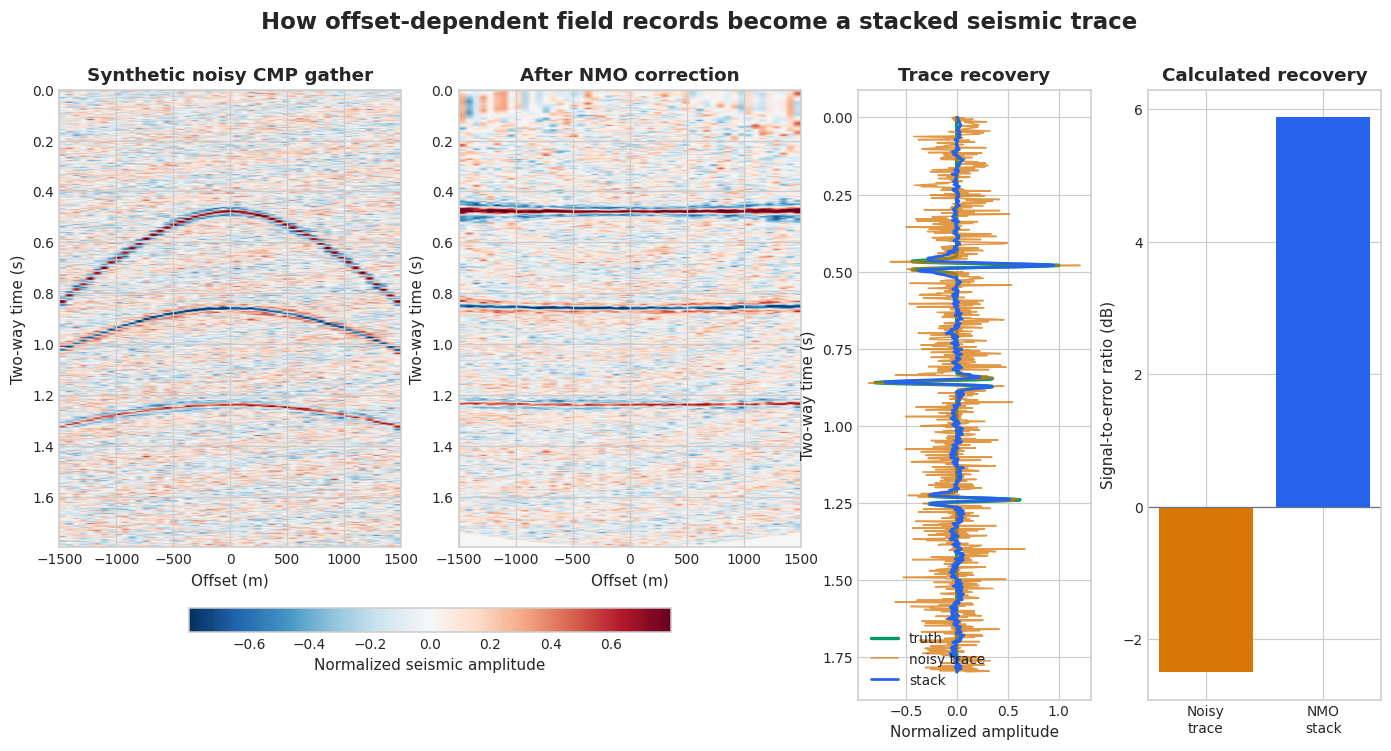

In [5]:
cmp_figure = plt.figure(figsize=(15.5, 7.2))
cmp_grid = cmp_figure.add_gridspec(1, 4, width_ratios=[1.25, 1.25, 0.85, 0.85])
gather_clip = np.quantile(np.abs(noisy_gather), 0.995)

gather_axis = cmp_figure.add_subplot(cmp_grid[0, 0])
gather_image = gather_axis.imshow(
    noisy_gather,
    cmap="RdBu_r",
    vmin=-gather_clip,
    vmax=gather_clip,
    aspect="auto",
    extent=[offsets_m.min(), offsets_m.max(), time_axis_s.max(), time_axis_s.min()],
)
gather_axis.set_title("Synthetic noisy CMP gather")
gather_axis.set_xlabel("Offset (m)")
gather_axis.set_ylabel("Two-way time (s)")

nmo_axis = cmp_figure.add_subplot(cmp_grid[0, 1])
nmo_axis.imshow(
    nmo_gather,
    cmap="RdBu_r",
    vmin=-gather_clip,
    vmax=gather_clip,
    aspect="auto",
    extent=[offsets_m.min(), offsets_m.max(), time_axis_s.max(), time_axis_s.min()],
)
nmo_axis.set_title("After NMO correction")
nmo_axis.set_xlabel("Offset (m)")
nmo_axis.set_ylabel("Two-way time (s)")

trace_axis = cmp_figure.add_subplot(cmp_grid[0, 2])
trace_axis.plot(
    zero_offset_truth,
    time_axis_s,
    color=COLORS["reference"],
    linewidth=2.2,
    label="truth",
)
trace_axis.plot(
    center_trace,
    time_axis_s,
    color=COLORS["input"],
    alpha=0.75,
    linewidth=1.0,
    label="noisy trace",
)
trace_axis.plot(
    stacked_trace,
    time_axis_s,
    color=COLORS["processed"],
    linewidth=1.8,
    label="stack",
)
trace_axis.invert_yaxis()
trace_axis.set_title("Trace recovery")
trace_axis.set_xlabel("Normalized amplitude")
trace_axis.set_ylabel("Two-way time (s)")
trace_axis.legend(loc="lower left")

metric_axis = cmp_figure.add_subplot(cmp_grid[0, 3])
metric_axis.bar(
    ["Noisy\ntrace", "NMO\nstack"],
    cmp_metrics["signal-to-error ratio (dB)"],
    color=[COLORS["input"], COLORS["processed"]],
)
metric_axis.axhline(0.0, color="#64748B", linewidth=0.8)
metric_axis.set_title("Calculated recovery")
metric_axis.set_ylabel("Signal-to-error ratio (dB)")

cmp_figure.colorbar(
    gather_image,
    ax=[gather_axis, nmo_axis],
    location="bottom",
    shrink=0.65,
    pad=0.10,
    label="Normalized seismic amplitude",
)
cmp_figure.suptitle(
    "How offset-dependent field records become a stacked seismic trace",
    fontsize=15,
    weight="bold",
)
save_figure(cmp_figure, "02_cmp_nmo_stack_calculation.png")
plt.show()

### What the compact processing calculation omits

The calculation above demonstrates moveout and stacking, but production processing also needs
survey geometry, source/receiver corrections, deghosting, statics, deconvolution, coherent-noise
and multiple attenuation, anisotropic velocity analysis, migration, amplitude-preserving QC, and
uncertainty documentation. RMS should receive the reviewed processing deliverables—not a raw
gather generated inside the geomodelling project.

The remainder of the notebook therefore starts from a **processed depth-migrated SEG-Y volume**.

## 2. Immutable public Reek input data

The executed interpretation uses synthetic Reek test data from
[`equinor/xtgeo-testdata`](https://github.com/equinor/xtgeo-testdata), pinned to commit
`cad17f24e22c19c6cefe6f647185395cc0a11add`. The repository identifies the data as synthetic
subsurface test data and releases them under LGPL v3.0.

The main seismic file is a processed **depth stack**, not raw field acquisition. Public RMS-format
reference surfaces, wells, and a fault polygon are used for deterministic teaching and validation.
The full reference surfaces are withheld from the tracker except for sparse seed controls and
final error calculation.

No authoritative EPSG identifier is supplied with these fixtures. Coordinates are therefore kept
as project-local Cartesian metres. A production package must replace this with the survey-approved
CRS, vertical datum, units, polarity, and naming convention before RMS import.

In [6]:
PUBLIC_INPUTS = [
    {
        "name": "reek_depth_stack.segy",
        "source": "cubes/reek/syntseis_20000101_seismic_depth_stack.segy",
        "sha256": "88cd8802ee3c7fc669e8e0f5f5e6c737a33dc09903bf7c29a3a33f1a4bb44a06",
        "bytes": 59408400,
        "role": "processed depth-migrated seismic",
    },
    {
        "name": "top_reek_reference.gri",
        "source": "surfaces/reek/1/topreek_rota.gri",
        "sha256": "1bd402b6c62e93ed74f5b660683f4da54fa2498ee206390853ce02501c725c2a",
        "bytes": 1003124,
        "role": "withheld top-horizon reference",
    },
    {
        "name": "base_reek_reference.gri",
        "source": "surfaces/reek/1/basereek_rota.gri",
        "sha256": "17359154762888ca4e33c2799efaf62154d377fdc36e757b25acb518aecb96a8",
        "bytes": 1003124,
        "role": "withheld base-horizon reference",
    },
    {
        "name": "top_reek_faults.pol",
        "source": "polygons/reek/1/top_upper_reek_faultpoly.pol",
        "sha256": "5bd61ab0bc8acaff886f33b76b35460eb8e4fb7dac21f98f177096a6f24fd114",
        "bytes": 31145,
        "role": "interpreter fault polygons",
    },
]

WELL_FILE_DATA = {
    "OP_1.w": (817737, "60726b25cdcbab1dbbdb4cb62aa5b0d24d2c9cd29e0638782a44223e7ca37a82"),
    "OP_2.w": (1206657, "f368fbded94f99cd290ba24038ee72bc0eb1307cbbfcde7cd96276e51bcefea3"),
    "OP_3.w": (1162809, "02f83452d4edc70182b3494774b5c79613531095ac1bf09ee0bc4fad5d4121d5"),
    "OP_4.w": (623697, "dd0b5fd9d95f885d1fadd271602f227a88be067cd77dde80a7f098d870d757a2"),
    "OP_5.w": (664185, "8d4829378fb3883ee90f5f39be8573568733cec9467251703ef617c943db5afc"),
    "OP_6.w": (139103, "ad45d5cf11c5dcb8ff52987a183a665a06f5203d97d7ff0aa667a77f269726a4"),
    "WI_1.w": (746001, "614b76db48dc1e90be8f9d423c98b296a5129609890f5bd21085c88b24283493"),
    "WI_2.w": (1559121, "f29ea8c16b3ea26524791a1d157c37990fc2057c9f5ed2ca3b55d50c2fab4c92"),
    "WI_3.w": (1694025, "8890505059f1f81cb6376826481af42b64e6ebe9a1b199cafabb3d3b95583b7b"),
}
for well_filename, (expected_bytes, expected_sha256) in WELL_FILE_DATA.items():
    PUBLIC_INPUTS.append(
        {
            "name": well_filename,
            "source": f"wells/reek/1/{well_filename}",
            "sha256": expected_sha256,
            "bytes": expected_bytes,
            "role": "RMS-format well trajectory and logs",
        }
    )


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def download_verified(item, attempts=3):
    target = INPUT_DIRECTORY / item["name"]
    if target.exists():
        current_hash = sha256_file(target)
        if current_hash == item["sha256"] and target.stat().st_size == item["bytes"]:
            return target
        target.unlink()
    url = f"{DATA_ROOT}/{item['source']}"
    last_error = None
    for attempt in range(1, attempts + 1):
        try:
            urlretrieve(url, target)
            break
        except Exception as error:
            last_error = error
            if target.exists():
                target.unlink()
            if attempt == attempts:
                raise RuntimeError(f"Download failed after {attempts} attempts: {url}") from error
            time.sleep(attempt)
    if last_error is not None and not target.exists():
        raise RuntimeError(f"No downloaded file was created for {url}") from last_error
    actual_hash = sha256_file(target)
    actual_bytes = target.stat().st_size
    if actual_hash != item["sha256"] or actual_bytes != item["bytes"]:
        raise ValueError(f"Integrity mismatch for {item['name']}")
    return target


input_paths = {}
input_rows = []
for input_item in PUBLIC_INPUTS:
    resolved_path = download_verified(input_item)
    input_paths[input_item["name"]] = resolved_path
    input_rows.append(
        {
            "file": input_item["name"],
            "role": input_item["role"],
            "size (MB)": resolved_path.stat().st_size / 1e6,
            "SHA-256 verified": sha256_file(resolved_path) == input_item["sha256"],
        }
    )

input_inventory = pd.DataFrame(input_rows)
display(input_inventory.round({"size (MB)": 3}))
print("Pinned data commit:", DATA_COMMIT)
print("Declared source licence:", DATA_LICENSE)

Pinned data commit: cad17f24e22c19c6cefe6f647185395cc0a11add
Declared source licence: LGPL-3.0


,file,role,size (MB),SHA-256 verified
0,reek_depth_stack.segy,processed depth-migrated seismic,59.408,True
1,top_reek_reference.gri,withheld top-horizon reference,1.003,True
2,base_reek_reference.gri,withheld base-horizon reference,1.003,True
3,top_reek_faults.pol,interpreter fault polygons,0.031,True
4,OP_1.w,RMS-format well trajectory and logs,0.818,True
5,OP_2.w,RMS-format well trajectory and logs,1.207,True
6,OP_3.w,RMS-format well trajectory and logs,1.163,True
7,OP_4.w,RMS-format well trajectory and logs,0.624,True
8,OP_5.w,RMS-format well trajectory and logs,0.664,True
9,OP_6.w,RMS-format well trajectory and logs,0.139,True


In [7]:
seismic_cube = xtgeo.cube_from_file(input_paths["reek_depth_stack.segy"])
top_reference_full = xtgeo.surface_from_file(input_paths["top_reek_reference.gri"])
base_reference_full = xtgeo.surface_from_file(input_paths["base_reek_reference.gri"])
fault_polygons = xtgeo.polygons_from_file(input_paths["top_reek_faults.pol"])
wells = {
    Path(filename).stem: xtgeo.well_from_file(input_paths[filename])
    for filename in WELL_FILE_DATA
}

cube_surface_template = xtgeo.surface_from_cube(seismic_cube, 0.0)
x_grid_m, y_grid_m = cube_surface_template.get_xy_values(asmasked=False)
depth_axis_m = seismic_cube.zori + np.arange(seismic_cube.nlay) * seismic_cube.zinc

with segyio.open(
    str(input_paths["reek_depth_stack.segy"]),
    mode="r",
    strict=False,
    ignore_geometry=True,
) as segy_file:
    segy_trace_count = segy_file.tracecount
    segy_sample_count = len(segy_file.samples)
    segy_format_code = int(segy_file.bin[segyio.BinField.Format])
    segy_binary_interval = int(segy_file.bin[segyio.BinField.Interval])

geometry_table = pd.DataFrame(
    {
        "item": [
            "cube dimensions",
            "cube origin X/Y/Z",
            "cube increments X/Y/Z",
            "cube rotation",
            "cube handedness",
            "SEG-Y trace count",
            "SEG-Y samples per trace",
            "SEG-Y format code",
            "SEG-Y binary interval value",
            "reference surface nodes",
            "wells loaded",
            "fault polygon sets",
            "coordinate reference",
        ],
        "value": [
            f"{seismic_cube.ncol} × {seismic_cube.nrow} × {seismic_cube.nlay}",
            (
                f"{seismic_cube.xori:.2f} / {seismic_cube.yori:.2f} / "
                f"{seismic_cube.zori:.1f} m"
            ),
            (
                f"{seismic_cube.xinc:.3f} / {seismic_cube.yinc:.3f} / "
                f"{seismic_cube.zinc:.1f} m"
            ),
            f"{seismic_cube.rotation:.3f}° anticlockwise from East",
            f"YFLIP = {seismic_cube.yflip}",
            f"{segy_trace_count:,}",
            f"{segy_sample_count}",
            str(segy_format_code),
            str(segy_binary_interval),
            f"{top_reference_full.ncol} × {top_reference_full.nrow}",
            str(len(wells)),
            str(fault_polygons.dataframe["POLY_ID"].nunique()),
            "project-local Cartesian metres; EPSG intentionally unset",
        ],
    }
)
display(geometry_table)

,item,value
0,cube dimensions,408 × 280 × 70
1,cube origin X/Y/Z,461492.32 / 5926799.36 / 1550.0 m
2,cube increments X/Y/Z,25.003 / 25.035 / 5.0 m
3,cube rotation,120.002° anticlockwise from East
4,cube handedness,YFLIP = -1
5,SEG-Y trace count,"114,240"
6,SEG-Y samples per trace,70
7,SEG-Y format code,1
8,SEG-Y binary interval value,5000
9,reference surface nodes,554 × 451


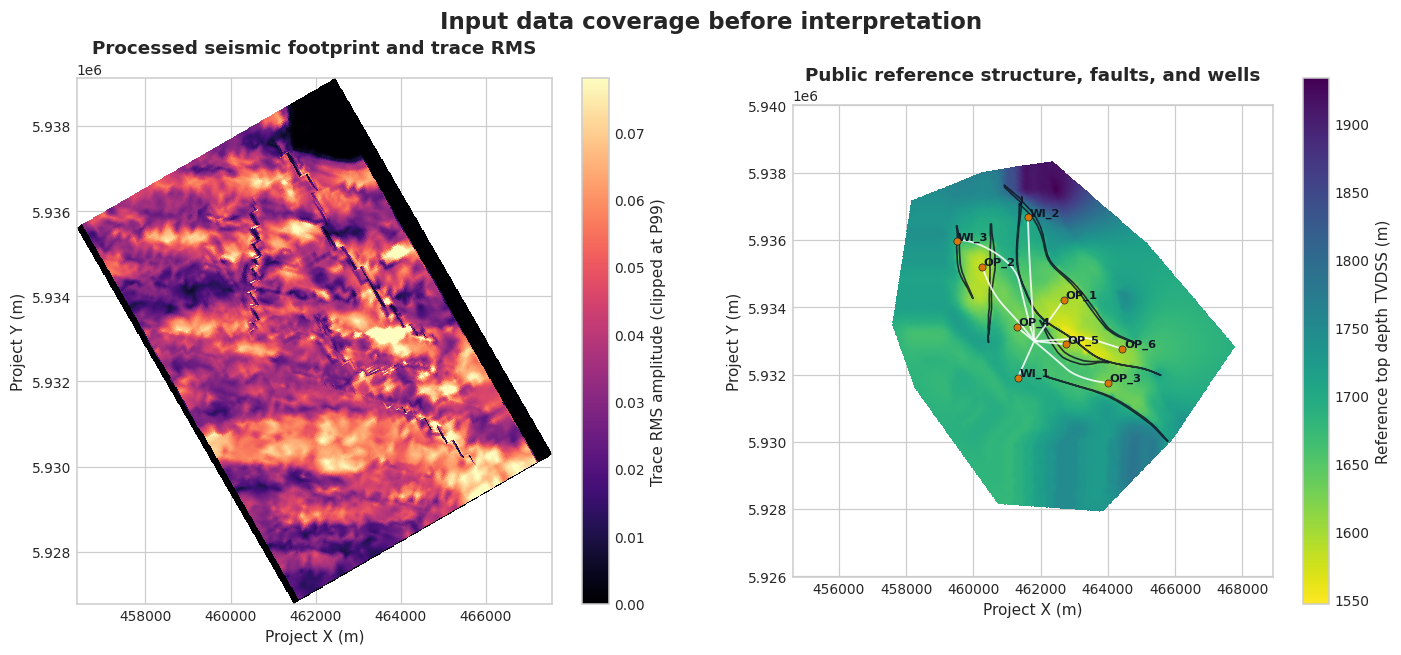

In [8]:
raw_values = np.asarray(seismic_cube.values)
trace_rms_raw = np.sqrt(np.mean(raw_values**2, axis=2))
surface_mask = np.ma.getmaskarray(top_reference_full.values)

footprint_figure, footprint_axes = plt.subplots(1, 2, figsize=(15.5, 6.2))
energy_limit = np.quantile(trace_rms_raw[trace_rms_raw > 0.0], 0.99)
energy_image = footprint_axes[0].pcolormesh(
    x_grid_m,
    y_grid_m,
    np.clip(trace_rms_raw, 0.0, energy_limit),
    cmap="magma",
    shading="auto",
)
footprint_axes[0].set_title("Processed seismic footprint and trace RMS")
footprint_axes[0].set_xlabel("Project X (m)")
footprint_axes[0].set_ylabel("Project Y (m)")
footprint_axes[0].set_aspect("equal")
footprint_figure.colorbar(
    energy_image,
    ax=footprint_axes[0],
    label="Trace RMS amplitude (clipped at P99)",
)

top_map = footprint_axes[1].pcolormesh(
    *top_reference_full.get_xy_values(asmasked=False),
    top_reference_full.values,
    cmap="viridis_r",
    shading="auto",
)
for polygon_id, polygon_frame in fault_polygons.dataframe.groupby("POLY_ID"):
    footprint_axes[1].plot(
        polygon_frame["X_UTME"],
        polygon_frame["Y_UTMN"],
        color="#111827",
        linewidth=1.1,
        alpha=0.85,
    )

for well_name, well in wells.items():
    well_frame = well.dataframe
    footprint_axes[1].plot(
        well_frame["X_UTME"].iloc[::80],
        well_frame["Y_UTMN"].iloc[::80],
        color="white",
        linewidth=1.2,
        alpha=0.85,
    )
    footprint_axes[1].scatter(
        well_frame["X_UTME"].iloc[-1],
        well_frame["Y_UTMN"].iloc[-1],
        s=22,
        color=COLORS["input"],
        edgecolor="#111827",
        linewidth=0.4,
        zorder=5,
    )
    footprint_axes[1].text(
        well_frame["X_UTME"].iloc[-1] + 45.0,
        well_frame["Y_UTMN"].iloc[-1] + 45.0,
        well_name,
        fontsize=7.5,
        color="#111827",
        weight="bold",
    )

footprint_axes[1].set_title("Public reference structure, faults, and wells")
footprint_axes[1].set_xlabel("Project X (m)")
footprint_axes[1].set_ylabel("Project Y (m)")
footprint_axes[1].set_aspect("equal")
footprint_figure.colorbar(
    top_map,
    ax=footprint_axes[1],
    label="Reference top depth TVDSS (m)",
)
footprint_figure.suptitle(
    "Input data coverage before interpretation",
    fontsize=15,
    weight="bold",
)
save_figure(footprint_figure, "03_input_footprint.png")
plt.show()

## 3. SEG-Y geometry and amplitude quality control

Before interpretation, a production team verifies survey geometry, inline/crossline numbering,
coordinate scalars, sample interval, time/depth domain, polarity, datum, dead traces, amplitude
statistics, footprint, and processing history. Header values are never accepted without comparing
them with navigation and project metadata.

The Reek volume contains six isolated extreme traces and several zero-energy traces. The next
calculation detects the extremes from a robust peak-amplitude threshold and replaces only those
traces with the median of valid neighbouring traces. It does not apply automatic gain control or
global normalization, so relative amplitudes remain available for attribute screening.

In [9]:
trace_peak_raw = np.max(np.abs(raw_values), axis=2)
active_trace_mask = trace_rms_raw > 0.0
robust_peak_p999 = np.quantile(trace_peak_raw[active_trace_mask], 0.999)
outlier_limit = 2.0 * robust_peak_p999
outlier_trace_mask = trace_peak_raw > outlier_limit
outlier_indices = np.argwhere(outlier_trace_mask)

conditioned_values = raw_values.copy()
for inline_index, crossline_index in outlier_indices:
    inline_start = max(inline_index - 1, 0)
    inline_stop = min(inline_index + 2, seismic_cube.ncol)
    crossline_start = max(crossline_index - 1, 0)
    crossline_stop = min(crossline_index + 2, seismic_cube.nrow)
    neighbours = conditioned_values[
        inline_start:inline_stop,
        crossline_start:crossline_stop,
        :,
    ].reshape(-1, seismic_cube.nlay)
    neighbour_peak = np.max(np.abs(neighbours), axis=1)
    valid_neighbours = neighbours[neighbour_peak <= outlier_limit]
    conditioned_values[inline_index, crossline_index, :] = np.median(
        valid_neighbours,
        axis=0,
    )

conditioned_cube = seismic_cube.copy()
conditioned_cube.values = conditioned_values
trace_rms_conditioned = np.sqrt(np.mean(conditioned_values**2, axis=2))
trace_peak_conditioned = np.max(np.abs(conditioned_values), axis=2)
amplitude_clip = np.quantile(
    np.abs(conditioned_values[trace_rms_conditioned > 0.0]),
    0.995,
)

seismic_qc_table = pd.DataFrame(
    {
        "metric": [
            "total traces",
            "zero-energy traces",
            "robust P99.9 trace peak",
            "outlier threshold",
            "outlier traces repaired",
            "maximum raw amplitude",
            "maximum conditioned amplitude",
            "display amplitude clip (P99.5)",
        ],
        "value": [
            seismic_cube.ncol * seismic_cube.nrow,
            int(np.sum(~active_trace_mask)),
            robust_peak_p999,
            outlier_limit,
            len(outlier_indices),
            float(np.max(np.abs(raw_values))),
            float(np.max(np.abs(conditioned_values))),
            amplitude_clip,
        ],
    }
)
display(seismic_qc_table.round(6))

,metric,value
0,total traces,114240.000000
1,zero-energy traces,8634.000000
2,robust P99.9 trace peak,0.471377
3,outlier threshold,0.942753
4,outlier traces repaired,6.000000
5,maximum raw amplitude,93.812256
6,maximum conditioned amplitude,0.847528
7,display amplitude clip (P99.5),0.233572


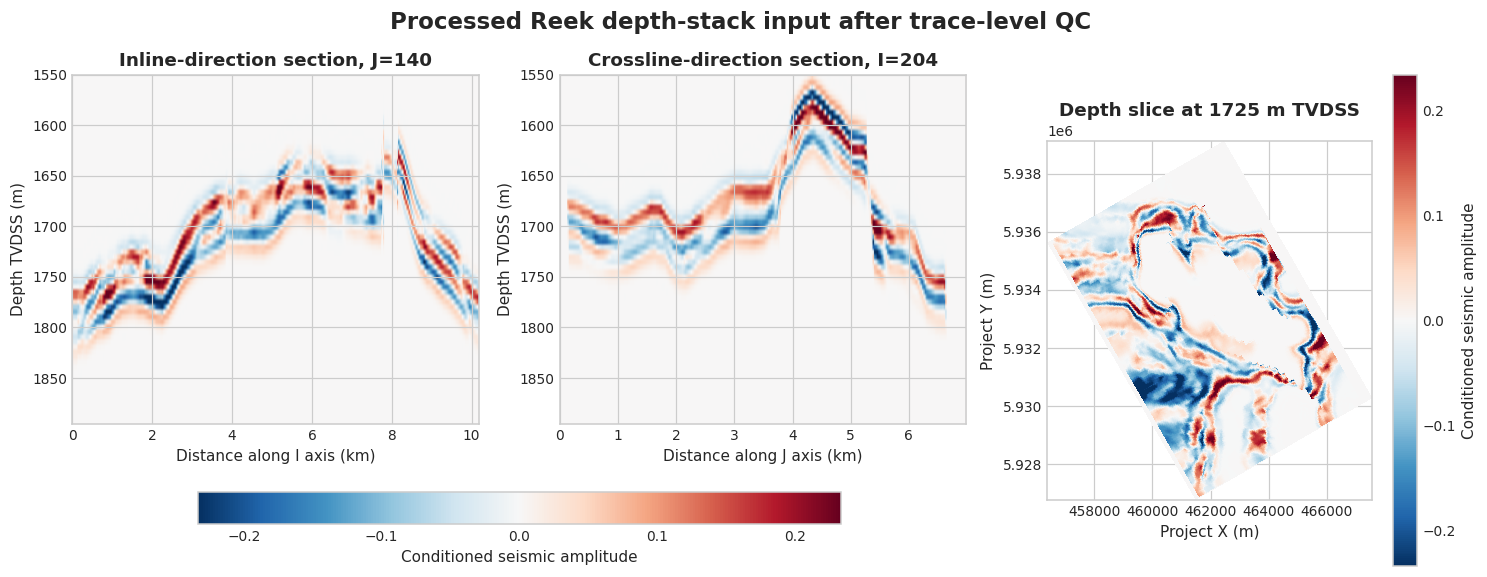

In [10]:
central_inline_index = seismic_cube.ncol // 2
central_crossline_index = seismic_cube.nrow // 2
central_depth_index = seismic_cube.nlay // 2
inline_distance_km = np.arange(seismic_cube.ncol) * seismic_cube.xinc / 1000.0
crossline_distance_km = np.arange(seismic_cube.nrow) * seismic_cube.yinc / 1000.0

seismic_figure, seismic_axes = plt.subplots(1, 3, figsize=(16.2, 5.8))
inline_image = seismic_axes[0].imshow(
    conditioned_values[:, central_crossline_index, :].T,
    cmap="RdBu_r",
    vmin=-amplitude_clip,
    vmax=amplitude_clip,
    aspect="auto",
    extent=[
        inline_distance_km.min(),
        inline_distance_km.max(),
        depth_axis_m.max(),
        depth_axis_m.min(),
    ],
)
seismic_axes[0].set_title(f"Inline-direction section, J={central_crossline_index}")
seismic_axes[0].set_xlabel("Distance along I axis (km)")
seismic_axes[0].set_ylabel("Depth TVDSS (m)")

seismic_axes[1].imshow(
    conditioned_values[central_inline_index, :, :].T,
    cmap="RdBu_r",
    vmin=-amplitude_clip,
    vmax=amplitude_clip,
    aspect="auto",
    extent=[
        crossline_distance_km.min(),
        crossline_distance_km.max(),
        depth_axis_m.max(),
        depth_axis_m.min(),
    ],
)
seismic_axes[1].set_title(f"Crossline-direction section, I={central_inline_index}")
seismic_axes[1].set_xlabel("Distance along J axis (km)")
seismic_axes[1].set_ylabel("Depth TVDSS (m)")

slice_image = seismic_axes[2].pcolormesh(
    x_grid_m,
    y_grid_m,
    conditioned_values[:, :, central_depth_index],
    cmap="RdBu_r",
    vmin=-amplitude_clip,
    vmax=amplitude_clip,
    shading="auto",
)
seismic_axes[2].set_title(f"Depth slice at {depth_axis_m[central_depth_index]:.0f} m TVDSS")
seismic_axes[2].set_xlabel("Project X (m)")
seismic_axes[2].set_ylabel("Project Y (m)")
seismic_axes[2].set_aspect("equal")

seismic_figure.colorbar(
    inline_image,
    ax=seismic_axes[:2],
    location="bottom",
    shrink=0.72,
    pad=0.14,
    label="Conditioned seismic amplitude",
)
seismic_figure.colorbar(
    slice_image,
    ax=seismic_axes[2],
    label="Conditioned seismic amplitude",
)
seismic_figure.suptitle(
    "Processed Reek depth-stack input after trace-level QC",
    fontsize=15,
    weight="bold",
)
save_figure(seismic_figure, "04_seismic_sections_and_slice.png")
plt.show()

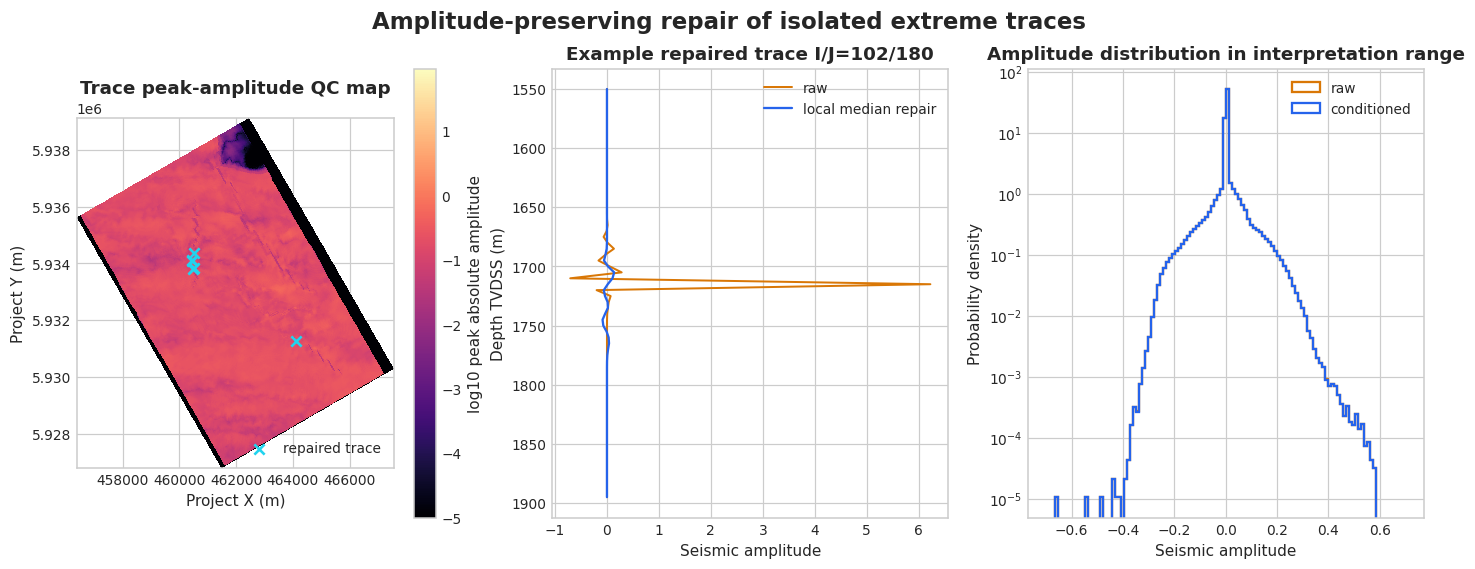

In [11]:
representative_outlier_i, representative_outlier_j = outlier_indices[0]
conditioning_figure, conditioning_axes = plt.subplots(1, 3, figsize=(15.8, 5.3))

peak_display = np.log10(trace_peak_raw + 1.0e-5)
peak_map = conditioning_axes[0].pcolormesh(
    x_grid_m,
    y_grid_m,
    peak_display,
    cmap="magma",
    shading="auto",
)
conditioning_axes[0].scatter(
    x_grid_m[outlier_trace_mask],
    y_grid_m[outlier_trace_mask],
    marker="x",
    s=45,
    linewidth=1.7,
    color="#22D3EE",
    label="repaired trace",
)
conditioning_axes[0].set_title("Trace peak-amplitude QC map")
conditioning_axes[0].set_xlabel("Project X (m)")
conditioning_axes[0].set_ylabel("Project Y (m)")
conditioning_axes[0].set_aspect("equal")
conditioning_axes[0].legend(loc="lower right")
conditioning_figure.colorbar(
    peak_map,
    ax=conditioning_axes[0],
    label="log10 peak absolute amplitude",
)

conditioning_axes[1].plot(
    raw_values[representative_outlier_i, representative_outlier_j, :],
    depth_axis_m,
    color=COLORS["input"],
    linewidth=1.3,
    label="raw",
)
conditioning_axes[1].plot(
    conditioned_values[representative_outlier_i, representative_outlier_j, :],
    depth_axis_m,
    color=COLORS["processed"],
    linewidth=1.5,
    label="local median repair",
)
conditioning_axes[1].invert_yaxis()
conditioning_axes[1].set_title(
    f"Example repaired trace I/J={representative_outlier_i}/{representative_outlier_j}"
)
conditioning_axes[1].set_xlabel("Seismic amplitude")
conditioning_axes[1].set_ylabel("Depth TVDSS (m)")
conditioning_axes[1].legend()

histogram_range = (-3.0 * amplitude_clip, 3.0 * amplitude_clip)
conditioning_axes[2].hist(
    raw_values.ravel(),
    bins=120,
    range=histogram_range,
    density=True,
    histtype="step",
    color=COLORS["input"],
    linewidth=1.5,
    label="raw",
)
conditioning_axes[2].hist(
    conditioned_values.ravel(),
    bins=120,
    range=histogram_range,
    density=True,
    histtype="step",
    color=COLORS["processed"],
    linewidth=1.5,
    label="conditioned",
)
conditioning_axes[2].set_yscale("log")
conditioning_axes[2].set_title("Amplitude distribution in interpretation range")
conditioning_axes[2].set_xlabel("Seismic amplitude")
conditioning_axes[2].set_ylabel("Probability density")
conditioning_axes[2].legend()

conditioning_figure.suptitle(
    "Amplitude-preserving repair of isolated extreme traces",
    fontsize=15,
    weight="bold",
)
save_figure(conditioning_figure, "05_trace_conditioning_qc.png")
plt.show()

## 4. Well trajectories, markers, and petrophysical logs

The public Reek RMS wells contain trajectory coordinates, a discrete zone log, porosity,
permeability, and facies. Eight wells contain reservoir properties; `OP_6` is a trajectory-only
case. For this teaching workflow:

- the first sample with zone code 1 is the top marker;
- the first sample with zone code 4 is the base marker;
- reservoir-average porosity is arithmetic;
- reservoir-average permeability is geometric because permeability spans orders of magnitude.

These rules are explicit and reproducible. A real asset must use the approved stratigraphic
marker set, log edits, environmental corrections, core calibration, saturation-height model,
and petrophysical uncertainty.

In [12]:
def nearest_trace_index(x_value_m, y_value_m):
    distance_squared = (x_grid_m - x_value_m) ** 2 + (y_grid_m - y_value_m) ** 2
    return np.unravel_index(np.argmin(distance_squared), distance_squared.shape)


well_rows = []
for well_name, well in wells.items():
    well_frame = well.dataframe.copy()
    if "Zonelog" not in well_frame:
        continue
    zone_values = well_frame["Zonelog"].to_numpy()
    top_candidates = np.flatnonzero(zone_values >= 1)
    base_candidates = np.flatnonzero(zone_values >= 4)
    top_index = int(top_candidates[0])
    base_index = int(base_candidates[0])
    top_depth_m = float(well_frame.iloc[top_index]["Z_TVDSS"])
    base_depth_m = float(well_frame.iloc[base_index]["Z_TVDSS"])
    middle_depth_m = 0.5 * (top_depth_m + base_depth_m)
    middle_index = int(
        np.argmin(np.abs(well_frame["Z_TVDSS"].to_numpy() - middle_depth_m))
    )
    reservoir_mask = (
        np.isfinite(well_frame["Poro"])
        & (zone_values >= 1)
        & (zone_values < 4)
    )
    permeability_values = well_frame.loc[reservoir_mask, "Perm"].clip(lower=1.0e-6)
    midpoint_x_m = float(well_frame.iloc[middle_index]["X_UTME"])
    midpoint_y_m = float(well_frame.iloc[middle_index]["Y_UTMN"])
    trace_i, trace_j = nearest_trace_index(midpoint_x_m, midpoint_y_m)
    trace_distance_m = float(
        np.hypot(
            x_grid_m[trace_i, trace_j] - midpoint_x_m,
            y_grid_m[trace_i, trace_j] - midpoint_y_m,
        )
    )
    well_rows.append(
        {
            "well": well_name,
            "top depth TVDSS (m)": top_depth_m,
            "base depth TVDSS (m)": base_depth_m,
            "gross thickness (m)": base_depth_m - top_depth_m,
            "midpoint X (m)": midpoint_x_m,
            "midpoint Y (m)": midpoint_y_m,
            "mean porosity (-)": float(well_frame.loc[reservoir_mask, "Poro"].mean()),
            "geometric mean permeability (mD)": float(
                np.exp(np.mean(np.log(permeability_values)))
            ),
            "nearest trace I": int(trace_i),
            "nearest trace J": int(trace_j),
            "trace distance (m)": trace_distance_m,
        }
    )

well_summary = pd.DataFrame(well_rows).sort_values("well").reset_index(drop=True)
display(
    well_summary.round(
        {
            "top depth TVDSS (m)": 2,
            "base depth TVDSS (m)": 2,
            "gross thickness (m)": 2,
            "mean porosity (-)": 4,
            "geometric mean permeability (mD)": 2,
            "trace distance (m)": 2,
        }
    )
)

,well,top depth TVDSS (m),base depth TVDSS (m),gross thickness (m),midpoint X (m),midpoint Y (m),mean porosity (-),geometric mean permeability (mD),nearest trace I,nearest trace J,trace distance (m)
0,OP_1,1600.09,1643.66,43.57,462698.321,5934228.012,0.1838,125.64,233,190,5.05
1,OP_2,1585.50,1626.38,40.88,460264.644,5935209.038,0.1743,127.14,316,126,13.18
2,OP_3,1630.06,1673.13,43.08,464010.938,5931756.943,0.1373,16.07,121,186,9.26
3,OP_4,1640.62,1680.95,40.33,461288.683,5933415.029,0.1759,99.79,233,125,5.77
4,OP_5,1603.06,1644.87,41.81,462749.506,5932898.493,0.1124,10.05,186,165,8.20
5,WI_1,1695.25,1732.74,37.49,461317.537,5931897.943,0.1792,111.21,180,96,5.69
6,WI_2,1711.62,1749.91,38.29,461622.060,5936672.575,0.1624,88.75,339,202,12.08
7,WI_3,1708.37,1746.73,38.36,459510.571,5935967.131,0.1832,114.38,357,115,11.77


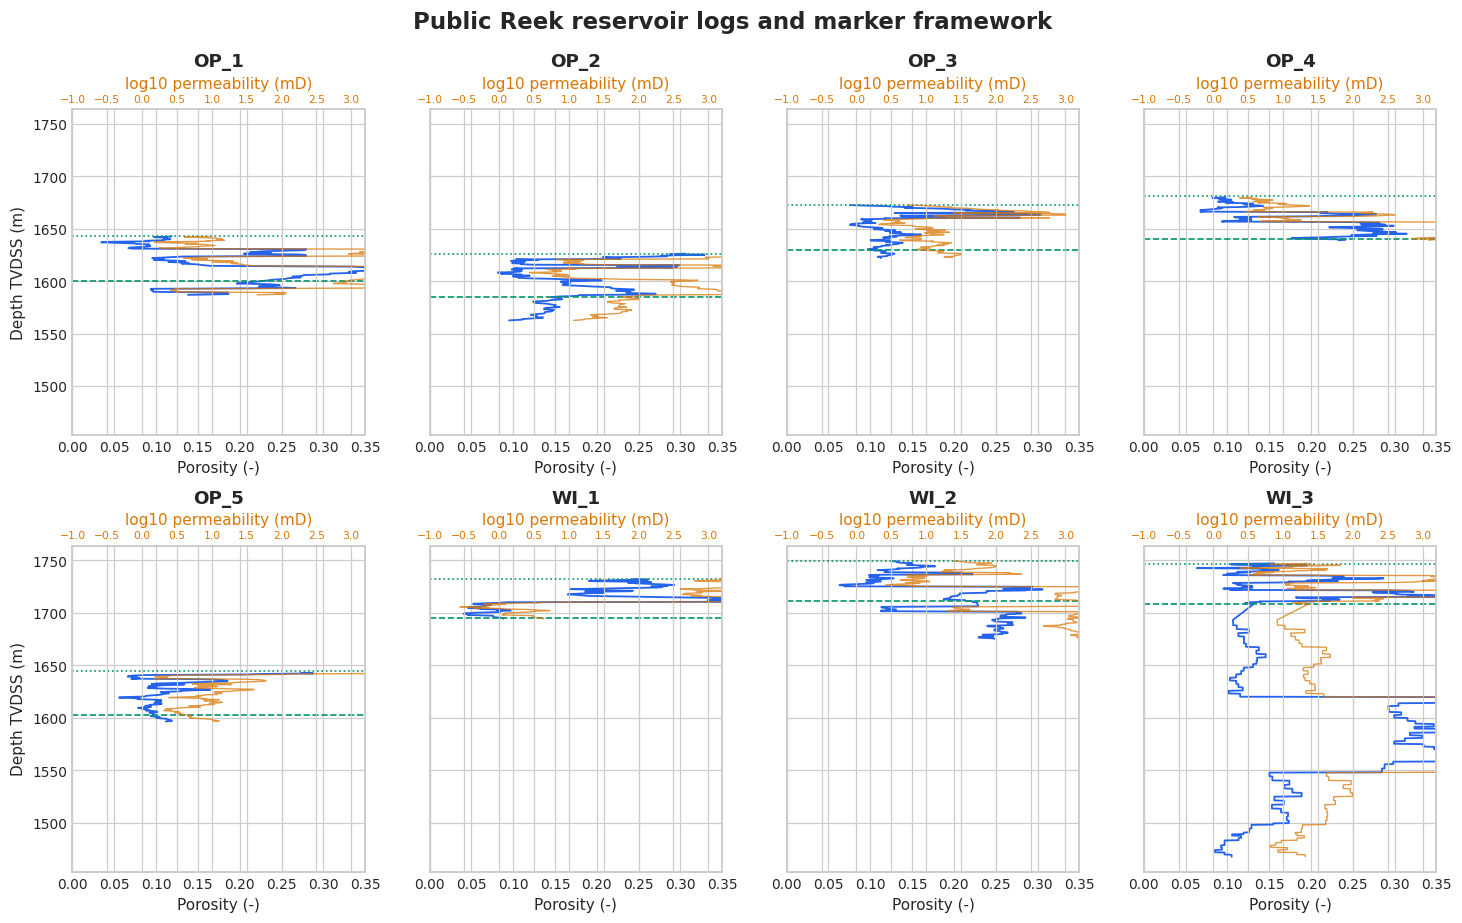

In [13]:
property_well_names = well_summary["well"].tolist()
well_log_figure, well_log_axes = plt.subplots(2, 4, figsize=(16.0, 9.0), sharey=True)

for axis, well_name in zip(well_log_axes.ravel(), property_well_names):
    well_frame = wells[well_name].dataframe
    summary_row = well_summary.loc[well_summary["well"].eq(well_name)].iloc[0]
    valid_log = np.isfinite(well_frame["Poro"])
    depth_values = well_frame.loc[valid_log, "Z_TVDSS"]
    porosity_values = well_frame.loc[valid_log, "Poro"]
    permeability_values = well_frame.loc[valid_log, "Perm"].clip(lower=1.0e-3)

    axis.plot(
        porosity_values,
        depth_values,
        color=COLORS["processed"],
        linewidth=1.2,
        label="porosity",
    )
    axis.axhline(
        summary_row["top depth TVDSS (m)"],
        color=COLORS["reference"],
        linewidth=1.1,
        linestyle="--",
    )
    axis.axhline(
        summary_row["base depth TVDSS (m)"],
        color=COLORS["reference"],
        linewidth=1.1,
        linestyle=":",
    )
    axis.set_xlim(0.0, 0.35)
    axis.set_title(well_name)
    axis.set_xlabel("Porosity (-)")
    axis.invert_yaxis()

    permeability_axis = axis.twiny()
    permeability_axis.plot(
        np.log10(permeability_values),
        depth_values,
        color=COLORS["input"],
        linewidth=0.9,
        alpha=0.75,
    )
    permeability_axis.set_xlim(-1.0, 3.2)
    permeability_axis.set_xlabel("log10 permeability (mD)", color=COLORS["input"])
    permeability_axis.tick_params(axis="x", colors=COLORS["input"], labelsize=7)

for axis in well_log_axes[:, 0]:
    axis.set_ylabel("Depth TVDSS (m)")

well_log_figure.suptitle(
    "Public Reek reservoir logs and marker framework",
    fontsize=15,
    weight="bold",
)
well_log_figure.subplots_adjust(top=0.88, hspace=0.34, wspace=0.22)
save_figure(well_log_figure, "06_well_logs_and_markers.png")
plt.show()

## 5. Well-to-seismic tie and event phase

The Reek cube is already in depth, so no synthetic-seismogram time tie is required for the
executed horizon tracker. We still need an event-to-geological-marker phase correction. At each
well, the code finds the strongest positive event around the top marker and the strongest
negative event around the base marker. The median offset is rounded to one 5 m seismic sample.

The correction is data-driven from the well markers. It is then held fixed while the full
horizons are tracked and compared with the withheld reference surfaces.

In [14]:
def event_offset_at_marker(summary_row, marker_column, polarity, half_window_m=40.0):
    trace_i = int(summary_row["nearest trace I"])
    trace_j = int(summary_row["nearest trace J"])
    marker_depth_m = float(summary_row[marker_column])
    center_index = int(np.rint((marker_depth_m - seismic_cube.zori) / seismic_cube.zinc))
    half_samples = int(np.rint(half_window_m / seismic_cube.zinc))
    sample_indices = np.arange(
        max(center_index - half_samples, 0),
        min(center_index + half_samples + 1, seismic_cube.nlay),
    )
    amplitudes = conditioned_values[trace_i, trace_j, sample_indices]
    if polarity == "positive":
        selected_index = sample_indices[int(np.argmax(amplitudes))]
    else:
        selected_index = sample_indices[int(np.argmin(amplitudes))]
    event_depth_m = float(depth_axis_m[selected_index])
    return event_depth_m - marker_depth_m, event_depth_m


tie_rows = []
for _, summary_row in well_summary.iterrows():
    top_offset_m, top_event_depth_m = event_offset_at_marker(
        summary_row,
        "top depth TVDSS (m)",
        "positive",
    )
    base_offset_m, base_event_depth_m = event_offset_at_marker(
        summary_row,
        "base depth TVDSS (m)",
        "negative",
    )
    tie_rows.append(
        {
            "well": summary_row["well"],
            "top positive-event offset (m)": top_offset_m,
            "base negative-event offset (m)": base_offset_m,
            "top event depth (m)": top_event_depth_m,
            "base event depth (m)": base_event_depth_m,
        }
    )

well_tie_table = pd.DataFrame(tie_rows)
top_phase_shift_m = float(
    np.rint(
        well_tie_table["top positive-event offset (m)"].median()
        / seismic_cube.zinc
    )
    * seismic_cube.zinc
)
base_phase_shift_m = float(
    np.rint(
        well_tie_table["base negative-event offset (m)"].median()
        / seismic_cube.zinc
    )
    * seismic_cube.zinc
)
display(well_tie_table.round(2))
print("Top event-to-marker phase shift:", top_phase_shift_m, "m")
print("Base event-to-marker phase shift:", base_phase_shift_m, "m")

Top event-to-marker phase shift: 10.0 m
Base event-to-marker phase shift: -10.0 m


,well,top positive-event offset (m),base negative-event offset (m),top event depth (m),base event depth (m)
0,OP_1,4.91,-23.66,1605.0,1620.0
1,OP_2,19.50,-1.38,1605.0,1625.0
2,OP_3,-0.06,-23.13,1630.0,1650.0
3,OP_4,29.38,-20.95,1670.0,1660.0
4,OP_5,6.94,0.13,1610.0,1645.0
5,WI_1,-0.25,-17.74,1695.0,1715.0
6,WI_2,18.38,0.09,1730.0,1750.0
7,WI_3,11.63,-6.73,1720.0,1740.0


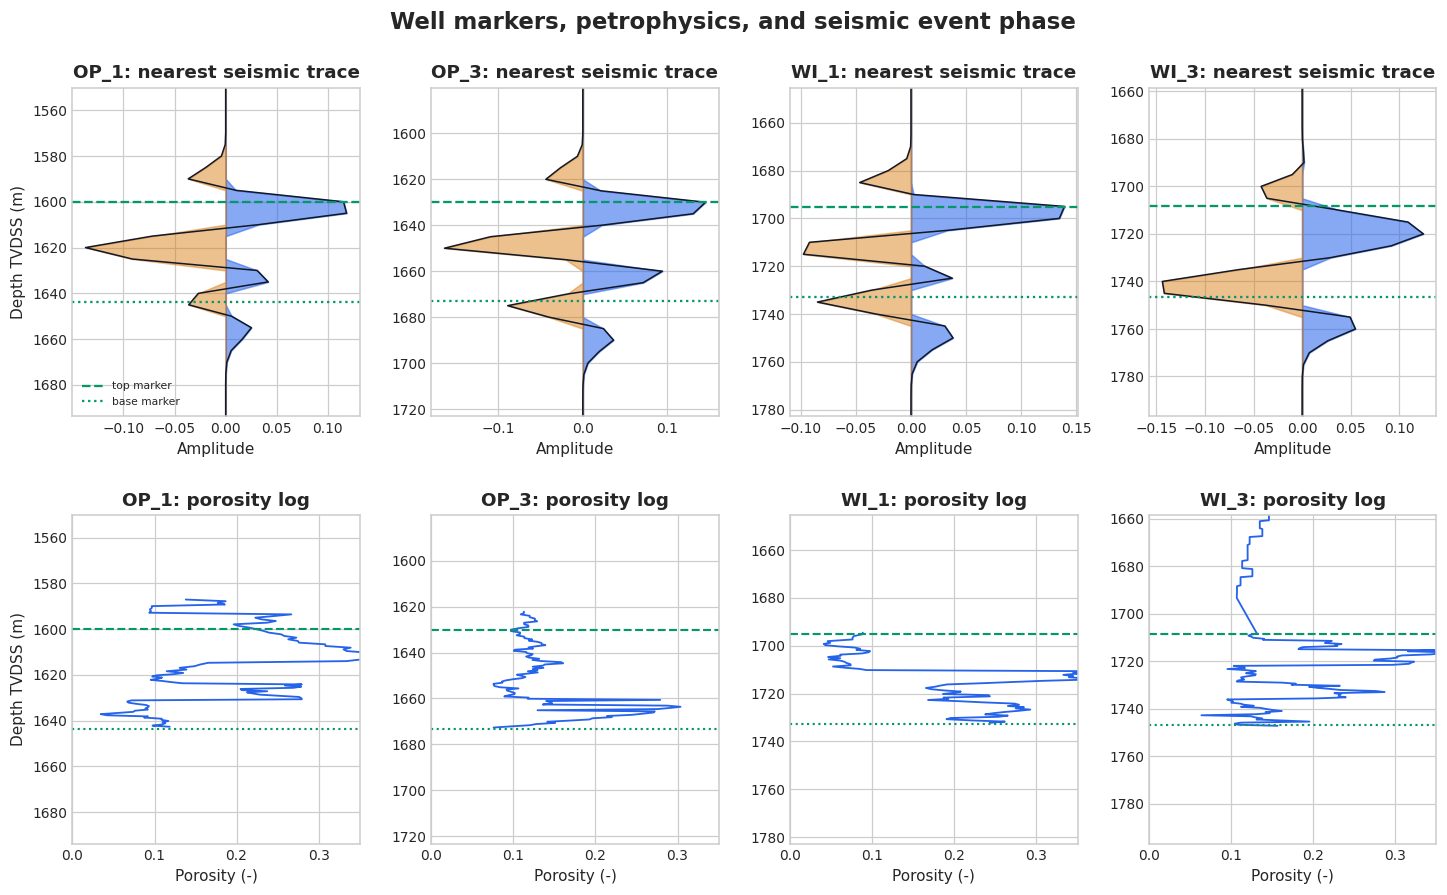

In [15]:
representative_wells = ["OP_1", "OP_3", "WI_1", "WI_3"]
tie_figure, tie_axes = plt.subplots(2, 4, figsize=(16.0, 8.7))

for column_index, well_name in enumerate(representative_wells):
    summary_row = well_summary.loc[well_summary["well"].eq(well_name)].iloc[0]
    trace_i = int(summary_row["nearest trace I"])
    trace_j = int(summary_row["nearest trace J"])
    trace_values = conditioned_values[trace_i, trace_j, :]

    seismic_axis = tie_axes[0, column_index]
    seismic_axis.plot(
        trace_values,
        depth_axis_m,
        color="#111827",
        linewidth=1.0,
    )
    seismic_axis.fill_betweenx(
        depth_axis_m,
        0.0,
        np.maximum(trace_values, 0.0),
        color=COLORS["processed"],
        alpha=0.55,
    )
    seismic_axis.fill_betweenx(
        depth_axis_m,
        0.0,
        np.minimum(trace_values, 0.0),
        color=COLORS["input"],
        alpha=0.45,
    )
    seismic_axis.axhline(
        summary_row["top depth TVDSS (m)"],
        color=COLORS["reference"],
        linestyle="--",
        linewidth=1.5,
        label="top marker",
    )
    seismic_axis.axhline(
        summary_row["base depth TVDSS (m)"],
        color=COLORS["reference"],
        linestyle=":",
        linewidth=1.5,
        label="base marker",
    )
    seismic_axis.set_ylim(
        summary_row["base depth TVDSS (m)"] + 50.0,
        summary_row["top depth TVDSS (m)"] - 50.0,
    )
    seismic_axis.set_title(f"{well_name}: nearest seismic trace")
    seismic_axis.set_xlabel("Amplitude")
    if column_index == 0:
        seismic_axis.set_ylabel("Depth TVDSS (m)")
        seismic_axis.legend(loc="lower left", fontsize=7)

    log_axis = tie_axes[1, column_index]
    well_frame = wells[well_name].dataframe
    valid_log = np.isfinite(well_frame["Poro"])
    log_axis.plot(
        well_frame.loc[valid_log, "Poro"],
        well_frame.loc[valid_log, "Z_TVDSS"],
        color=COLORS["processed"],
        linewidth=1.2,
    )
    log_axis.axhline(
        summary_row["top depth TVDSS (m)"],
        color=COLORS["reference"],
        linestyle="--",
        linewidth=1.4,
    )
    log_axis.axhline(
        summary_row["base depth TVDSS (m)"],
        color=COLORS["reference"],
        linestyle=":",
        linewidth=1.4,
    )
    log_axis.set_ylim(seismic_axis.get_ylim())
    log_axis.set_xlim(0.0, 0.35)
    log_axis.set_title(f"{well_name}: porosity log")
    log_axis.set_xlabel("Porosity (-)")
    if column_index == 0:
        log_axis.set_ylabel("Depth TVDSS (m)")

tie_figure.suptitle(
    "Well markers, petrophysics, and seismic event phase",
    fontsize=15,
    weight="bold",
)
tie_figure.subplots_adjust(top=0.90, hspace=0.30, wspace=0.25)
save_figure(tie_figure, "07_well_to_seismic_ties.png")
plt.show()

## 6. Seeded horizon tracking

A deterministic teaching tracker is used instead of an opaque machine-learning model. Sparse
control nodes are selected every 32 seismic traces from the public reference; this represents
interpreter-reviewed picks on a sparse line grid. The full reference map is withheld until the
error calculation.

At every trace, the seed depth defines a search window. For candidate sample $k$, the score is

$$J_i(k)=\frac{p_i A_i(k)}{A_{90}}-\lambda\left(\frac{k-k_{0,i}}{h}\right)^2$$

where $p_i$ is +1 for a positive event and -1 for a negative event, $A_i$ is amplitude,
$A_{90}$ is a robust scale, $k_{0,i}$ is the seed sample, $h$ is the half-window, and $\lambda$
penalizes jumps away from the seed. The well-derived phase shift converts the seismic event to
the geological marker. A one-trace Gaussian smoother suppresses isolated sample jumps.

Validation uses

$$\mathrm{RMSE}=\sqrt{\frac{1}{N}\sum_{i=1}^{N}\left(z_i^{\mathrm{pick}}-z_i^{\mathrm{ref}}\right)^2}$$

In [16]:
def reference_on_cube(reference_surface):
    result = xtgeo.surface_from_cube(seismic_cube, 0.0)
    result.resample(reference_surface)
    return result


def make_sparse_seed(reference_surface, spacing=32, vertical_margin_m=30.0):
    reference_values = np.ma.asarray(reference_surface.values)
    reference_array = np.asarray(reference_values)
    row_indices, column_indices = np.indices(reference_array.shape)
    valid_mask = (
        ~np.ma.getmaskarray(reference_values)
        & (reference_array >= depth_axis_m.min() + vertical_margin_m)
        & (reference_array <= depth_axis_m.max() - vertical_margin_m)
        & (trace_rms_conditioned > 0.0)
    )
    control_mask = (
        valid_mask
        & (row_indices % spacing == 0)
        & (column_indices % spacing == 0)
    )
    control_coordinates = np.column_stack(
        [row_indices[control_mask], column_indices[control_mask]]
    )
    control_values = reference_array[control_mask]
    query_coordinates = np.column_stack(
        [row_indices.ravel(), column_indices.ravel()]
    )
    linear_seed = griddata(
        control_coordinates,
        control_values,
        query_coordinates,
        method="linear",
    ).reshape(reference_array.shape)
    nearest_seed = griddata(
        control_coordinates,
        control_values,
        query_coordinates,
        method="nearest",
    ).reshape(reference_array.shape)
    seed_values = np.where(np.isfinite(linear_seed), linear_seed, nearest_seed)
    return seed_values, control_mask, valid_mask


top_reference_cube = reference_on_cube(top_reference_full)
base_reference_cube = reference_on_cube(base_reference_full)
top_seed, top_control_mask, top_reference_valid = make_sparse_seed(top_reference_cube)
base_seed, base_control_mask, base_reference_valid = make_sparse_seed(base_reference_cube)

control_summary = pd.DataFrame(
    {
        "horizon": ["top", "base"],
        "full validation nodes": [
            int(np.sum(top_reference_valid)),
            int(np.sum(base_reference_valid)),
        ],
        "sparse control nodes used": [
            int(np.sum(top_control_mask)),
            int(np.sum(base_control_mask)),
        ],
        "control fraction (%)": [
            100.0 * np.sum(top_control_mask) / np.sum(top_reference_valid),
            100.0 * np.sum(base_control_mask) / np.sum(base_reference_valid),
        ],
    }
)
display(control_summary.round(3))

,horizon,full validation nodes,sparse control nodes used,control fraction (%)
0,top,92379,87,0.094
1,base,92153,87,0.094


In [17]:
def track_seeded_event(
    seed_depth_m,
    valid_mask,
    polarity,
    phase_shift_m,
    half_window_samples=6,
    penalty_weight=1.0,
    smoothing_sigma=1.0,
):
    row_indices, column_indices = np.indices(seed_depth_m.shape)
    seed_indices = np.rint(
        (seed_depth_m - seismic_cube.zori) / seismic_cube.zinc
    ).astype(int)
    seed_indices = np.clip(seed_indices, 0, seismic_cube.nlay - 1)
    offsets = np.arange(-half_window_samples, half_window_samples + 1)
    candidate_indices = np.clip(
        seed_indices[..., None] + offsets,
        0,
        seismic_cube.nlay - 1,
    )
    candidate_amplitudes = np.take_along_axis(
        conditioned_values,
        candidate_indices,
        axis=2,
    )
    signed_amplitudes = (
        candidate_amplitudes if polarity == "positive" else -candidate_amplitudes
    )
    amplitude_scale = np.quantile(
        np.abs(candidate_amplitudes[valid_mask]),
        0.90,
    )
    distance_penalty = penalty_weight * (
        offsets / float(half_window_samples)
    ) ** 2
    scores = signed_amplitudes / amplitude_scale - distance_penalty
    selected_positions = np.argmax(scores, axis=2)
    selected_indices = candidate_indices[
        row_indices,
        column_indices,
        selected_positions,
    ]
    picked_depth_m = depth_axis_m[selected_indices] - phase_shift_m
    smoothed_depth_m = gaussian_filter(picked_depth_m, smoothing_sigma)
    return smoothed_depth_m, amplitude_scale


top_pick_m, top_amplitude_scale = track_seeded_event(
    top_seed,
    top_reference_valid,
    "positive",
    top_phase_shift_m,
)
base_pick_m, base_amplitude_scale = track_seeded_event(
    base_seed,
    base_reference_valid,
    "negative",
    base_phase_shift_m,
)

In [18]:
top_reference_array = np.ma.filled(top_reference_cube.values, np.nan)
base_reference_array = np.ma.filled(base_reference_cube.values, np.nan)
common_horizon_mask = (
    top_reference_valid
    & base_reference_valid
    & (base_pick_m > top_pick_m + 10.0)
    & (trace_rms_conditioned > 0.0)
)
top_residual_m = top_pick_m - top_reference_array
base_residual_m = base_pick_m - base_reference_array


def horizon_metrics(name, residual_m, picked_m, reference_m, valid_mask, controls):
    errors = residual_m[valid_mask]
    return {
        "horizon": name,
        "validation nodes": int(np.sum(valid_mask)),
        "control nodes": int(np.sum(controls)),
        "RMSE (m)": float(np.sqrt(np.mean(errors**2))),
        "MAE (m)": float(np.mean(np.abs(errors))),
        "bias (m)": float(np.mean(errors)),
        "P95 absolute error (m)": float(np.percentile(np.abs(errors), 95.0)),
        "depth correlation": float(
            np.corrcoef(picked_m[valid_mask], reference_m[valid_mask])[0, 1]
        ),
    }


horizon_metrics_table = pd.DataFrame(
    [
        horizon_metrics(
            "Top Reek",
            top_residual_m,
            top_pick_m,
            top_reference_array,
            top_reference_valid,
            top_control_mask,
        ),
        horizon_metrics(
            "Base Reek",
            base_residual_m,
            base_pick_m,
            base_reference_array,
            base_reference_valid,
            base_control_mask,
        ),
    ]
)

top_interpreted_surface = xtgeo.surface_from_cube(conditioned_cube, 0.0)
top_interpreted_surface.values = np.ma.array(
    top_pick_m,
    mask=~common_horizon_mask,
)
base_interpreted_surface = xtgeo.surface_from_cube(conditioned_cube, 0.0)
base_interpreted_surface.values = np.ma.array(
    base_pick_m,
    mask=~common_horizon_mask,
)
gross_thickness_surface = base_interpreted_surface - top_interpreted_surface

display(horizon_metrics_table.round(3))

,horizon,validation nodes,control nodes,RMSE (m),MAE (m),bias (m),P95 absolute error (m),depth correlation
0,Top Reek,92379,87,14.244,10.200,-3.187,31.268,0.954
1,Base Reek,92153,87,14.062,10.734,6.652,28.457,0.962


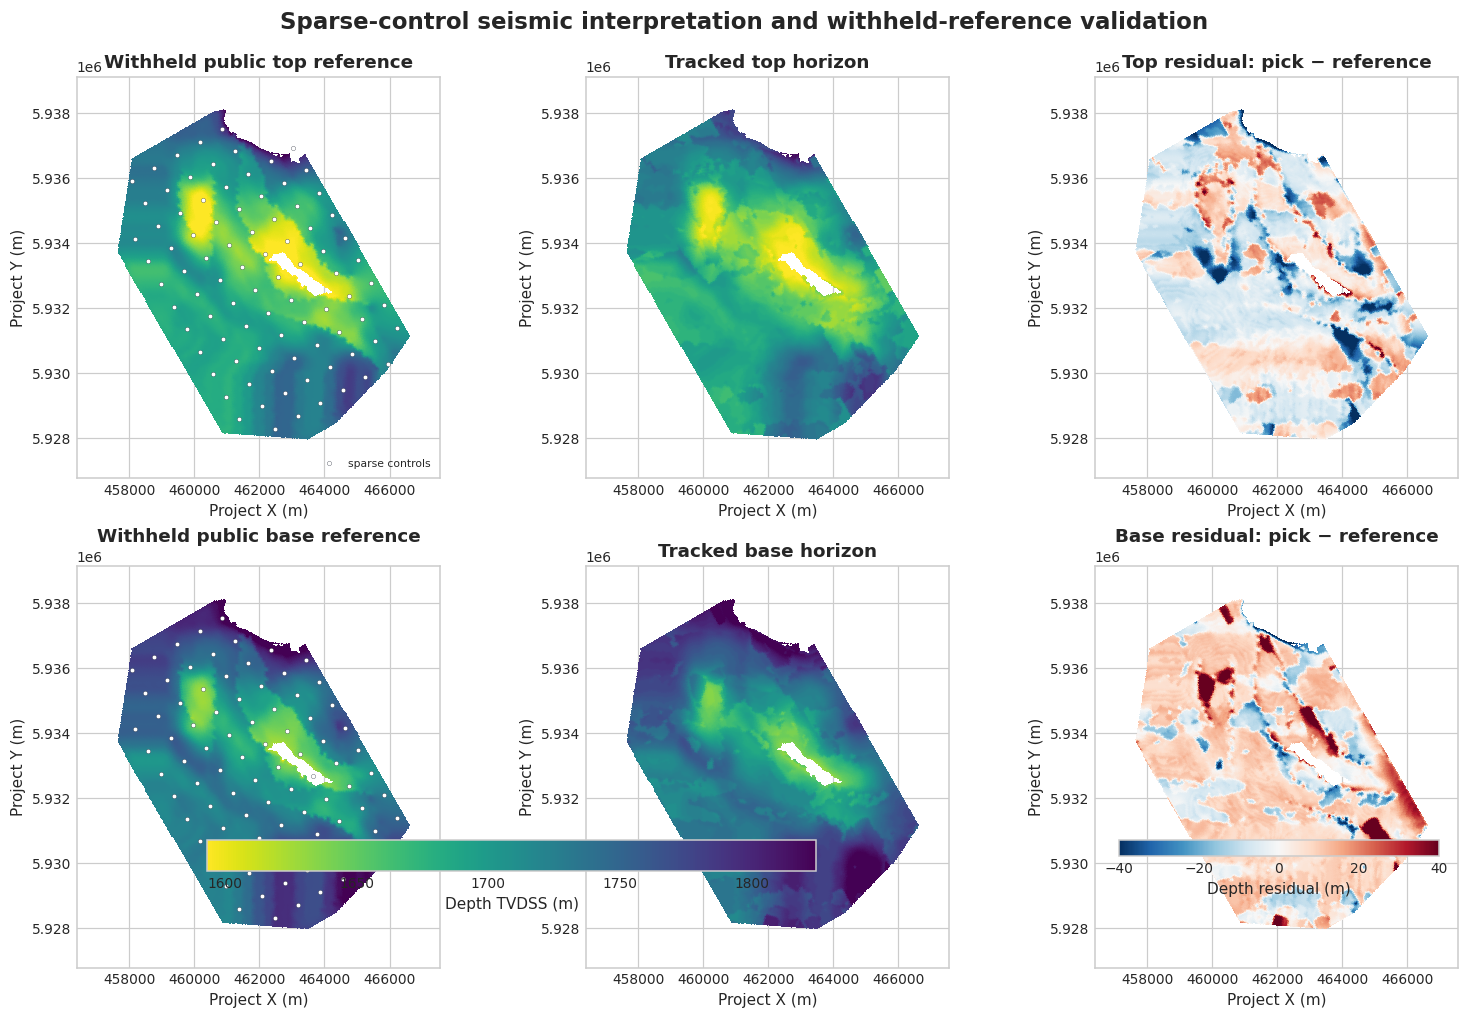

In [19]:
def draw_xy_surface(axis, values, title, cmap, limits=None):
    plot_values = np.ma.array(values, mask=~common_horizon_mask)
    options = {}
    if limits is not None:
        options["vmin"], options["vmax"] = limits
    image = axis.pcolormesh(
        x_grid_m,
        y_grid_m,
        plot_values,
        cmap=cmap,
        shading="auto",
        **options,
    )
    axis.set_title(title)
    axis.set_xlabel("Project X (m)")
    axis.set_ylabel("Project Y (m)")
    axis.set_aspect("equal")
    return image


depth_limits = (
    float(np.percentile(top_reference_array[top_reference_valid], 2.0)),
    float(np.percentile(base_reference_array[base_reference_valid], 98.0)),
)
residual_limit = 40.0
horizon_figure, horizon_axes = plt.subplots(2, 3, figsize=(17.0, 10.0))

top_reference_image = draw_xy_surface(
    horizon_axes[0, 0],
    top_reference_array,
    "Withheld public top reference",
    "viridis_r",
    depth_limits,
)
horizon_axes[0, 0].scatter(
    x_grid_m[top_control_mask],
    y_grid_m[top_control_mask],
    s=8,
    color="white",
    edgecolor="#111827",
    linewidth=0.2,
    label="sparse controls",
)
horizon_axes[0, 0].legend(loc="lower right", fontsize=7)
draw_xy_surface(
    horizon_axes[0, 1],
    top_pick_m,
    "Tracked top horizon",
    "viridis_r",
    depth_limits,
)
top_residual_image = draw_xy_surface(
    horizon_axes[0, 2],
    top_residual_m,
    "Top residual: pick − reference",
    "RdBu_r",
    (-residual_limit, residual_limit),
)

draw_xy_surface(
    horizon_axes[1, 0],
    base_reference_array,
    "Withheld public base reference",
    "viridis_r",
    depth_limits,
)
horizon_axes[1, 0].scatter(
    x_grid_m[base_control_mask],
    y_grid_m[base_control_mask],
    s=8,
    color="white",
    edgecolor="#111827",
    linewidth=0.2,
)
draw_xy_surface(
    horizon_axes[1, 1],
    base_pick_m,
    "Tracked base horizon",
    "viridis_r",
    depth_limits,
)
draw_xy_surface(
    horizon_axes[1, 2],
    base_residual_m,
    "Base residual: pick − reference",
    "RdBu_r",
    (-residual_limit, residual_limit),
)

horizon_figure.colorbar(
    top_reference_image,
    ax=horizon_axes[:, :2],
    location="bottom",
    shrink=0.65,
    pad=0.08,
    label="Depth TVDSS (m)",
)
horizon_figure.colorbar(
    top_residual_image,
    ax=horizon_axes[:, 2],
    location="bottom",
    shrink=0.75,
    pad=0.08,
    label="Depth residual (m)",
)
horizon_figure.suptitle(
    "Sparse-control seismic interpretation and withheld-reference validation",
    fontsize=15,
    weight="bold",
)
horizon_figure.subplots_adjust(top=0.92, hspace=0.22, wspace=0.18)
save_figure(horizon_figure, "08_horizon_tracking_and_errors.png")
plt.show()

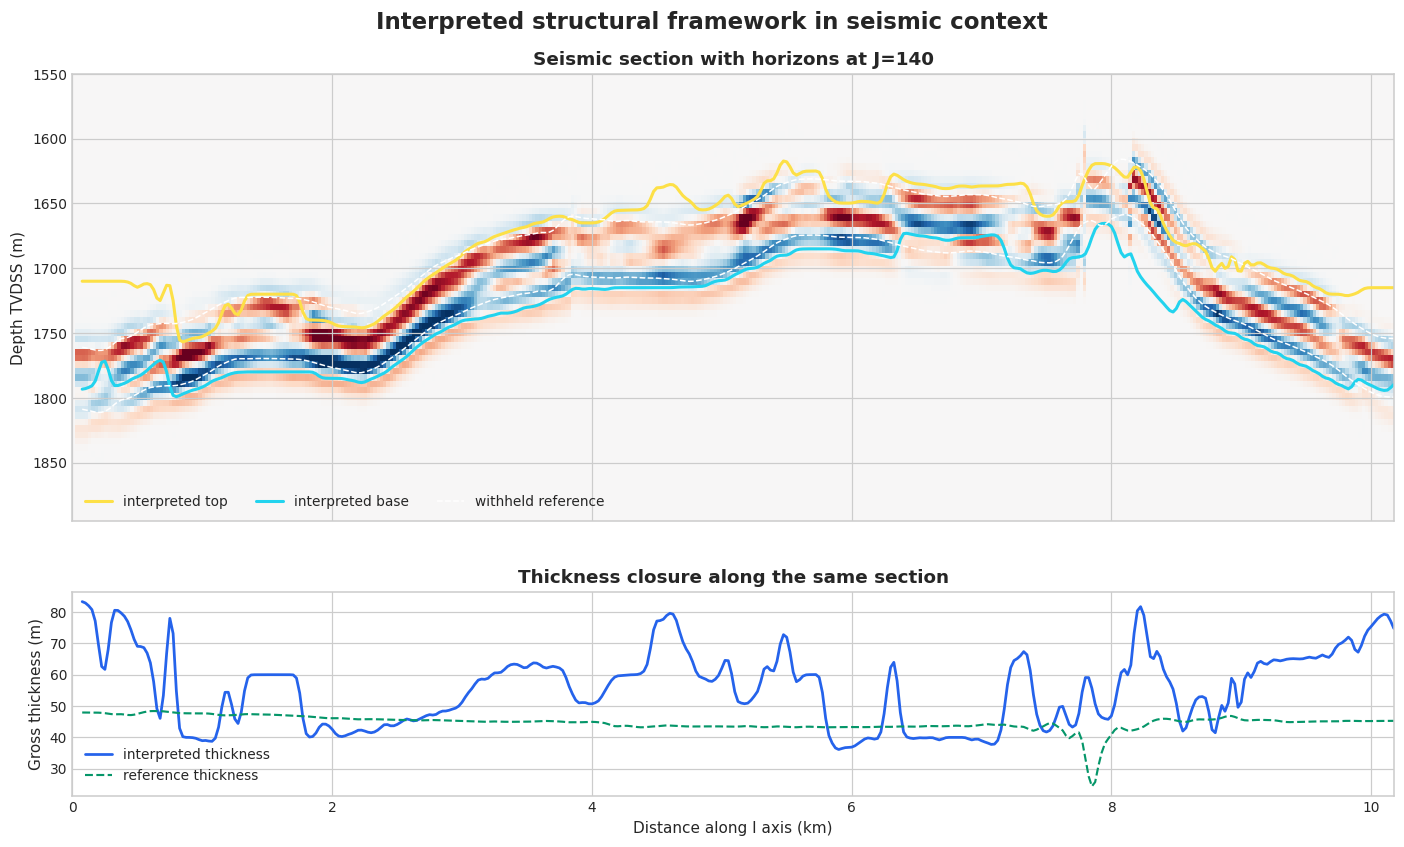

In [20]:
section_j = central_crossline_index
section_valid = common_horizon_mask[:, section_j]
section_top_pick_m = np.where(section_valid, top_pick_m[:, section_j], np.nan)
section_base_pick_m = np.where(section_valid, base_pick_m[:, section_j], np.nan)
section_top_reference_m = np.where(
    section_valid,
    top_reference_array[:, section_j],
    np.nan,
)
section_base_reference_m = np.where(
    section_valid,
    base_reference_array[:, section_j],
    np.nan,
)
section_figure, section_axes = plt.subplots(
    2,
    1,
    figsize=(15.5, 8.2),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1.0]},
)

section_axes[0].imshow(
    conditioned_values[:, section_j, :].T,
    cmap="RdBu_r",
    vmin=-amplitude_clip,
    vmax=amplitude_clip,
    aspect="auto",
    extent=[
        inline_distance_km.min(),
        inline_distance_km.max(),
        depth_axis_m.max(),
        depth_axis_m.min(),
    ],
)
section_axes[0].plot(
    inline_distance_km,
    section_top_pick_m,
    color="#FDE047",
    linewidth=2.0,
    label="interpreted top",
)
section_axes[0].plot(
    inline_distance_km,
    section_base_pick_m,
    color="#22D3EE",
    linewidth=2.0,
    label="interpreted base",
)
section_axes[0].plot(
    inline_distance_km,
    section_top_reference_m,
    color="white",
    linestyle="--",
    linewidth=1.0,
    label="withheld reference",
)
section_axes[0].plot(
    inline_distance_km,
    section_base_reference_m,
    color="white",
    linestyle="--",
    linewidth=1.0,
)
section_axes[0].set_ylabel("Depth TVDSS (m)")
section_axes[0].set_title(f"Seismic section with horizons at J={section_j}")
section_axes[0].legend(loc="lower left", ncol=3)

section_axes[1].plot(
    inline_distance_km,
    np.ma.filled(gross_thickness_surface.values[:, section_j], np.nan),
    color=COLORS["processed"],
    linewidth=1.8,
    label="interpreted thickness",
)
reference_thickness = section_base_reference_m - section_top_reference_m
section_axes[1].plot(
    inline_distance_km,
    reference_thickness,
    color=COLORS["reference"],
    linestyle="--",
    linewidth=1.4,
    label="reference thickness",
)
section_axes[1].set_xlabel("Distance along I axis (km)")
section_axes[1].set_ylabel("Gross thickness (m)")
section_axes[1].set_title("Thickness closure along the same section")
section_axes[1].legend()

section_figure.suptitle(
    "Interpreted structural framework in seismic context",
    fontsize=15,
    weight="bold",
)
section_figure.subplots_adjust(top=0.91, hspace=0.22)
save_figure(section_figure, "09_interpreted_seismic_section.png")
plt.show()

## 7. Fault support from a discontinuity proxy

The public fault polygons are treated as interpreter-reviewed inputs. To avoid accepting them
blindly, the code calculates a normalized lateral discontinuity proxy from the conditioned
seismic gradients. It then measures the distance from every seismic trace to the nearest polygon
point and compares discontinuity near the interpreted faults with the background.

This is a support calculation, not automatic fault extraction. Production fault interpretation
uses vertical sections, variance/coherence, curvature, spectral decomposition, fault sticks,
stratigraphic consistency, and geological review.

In [21]:
inline_gradient = np.gradient(conditioned_values, axis=0) / seismic_cube.xinc
crossline_gradient = np.gradient(conditioned_values, axis=1) / seismic_cube.yinc
discontinuity = np.sqrt(
    np.mean(inline_gradient**2 + crossline_gradient**2, axis=2)
)
normalized_discontinuity = discontinuity / (trace_rms_conditioned + 1.0e-6)

fault_xy = fault_polygons.dataframe[["X_UTME", "Y_UTMN"]].to_numpy()
fault_tree = cKDTree(fault_xy)
fault_distance_m, _ = fault_tree.query(
    np.column_stack([x_grid_m.ravel(), y_grid_m.ravel()])
)
fault_distance_m = fault_distance_m.reshape(x_grid_m.shape)
near_fault_mask = active_trace_mask & (fault_distance_m < 100.0)
background_mask = active_trace_mask & (fault_distance_m > 300.0)
near_fault_median = float(np.median(normalized_discontinuity[near_fault_mask]))
background_median = float(np.median(normalized_discontinuity[background_mask]))
fault_support_ratio = near_fault_median / background_median

discontinuity_surface = xtgeo.surface_from_cube(conditioned_cube, 0.0)
discontinuity_surface.values = np.ma.array(
    normalized_discontinuity,
    mask=~active_trace_mask,
)

fault_support_table = pd.DataFrame(
    {
        "population": ["within 100 m of fault polygon", "more than 300 m from fault"],
        "trace count": [int(np.sum(near_fault_mask)), int(np.sum(background_mask))],
        "median normalized discontinuity": [near_fault_median, background_median],
    }
)
display(fault_support_table.round(5))
print("Near-fault/background discontinuity ratio:", round(fault_support_ratio, 3))

Near-fault/background discontinuity ratio: 2.161


,population,trace count,median normalized discontinuity
0,within 100 m of fault polygon,9719,0.02135
1,more than 300 m from fault,78198,0.00988


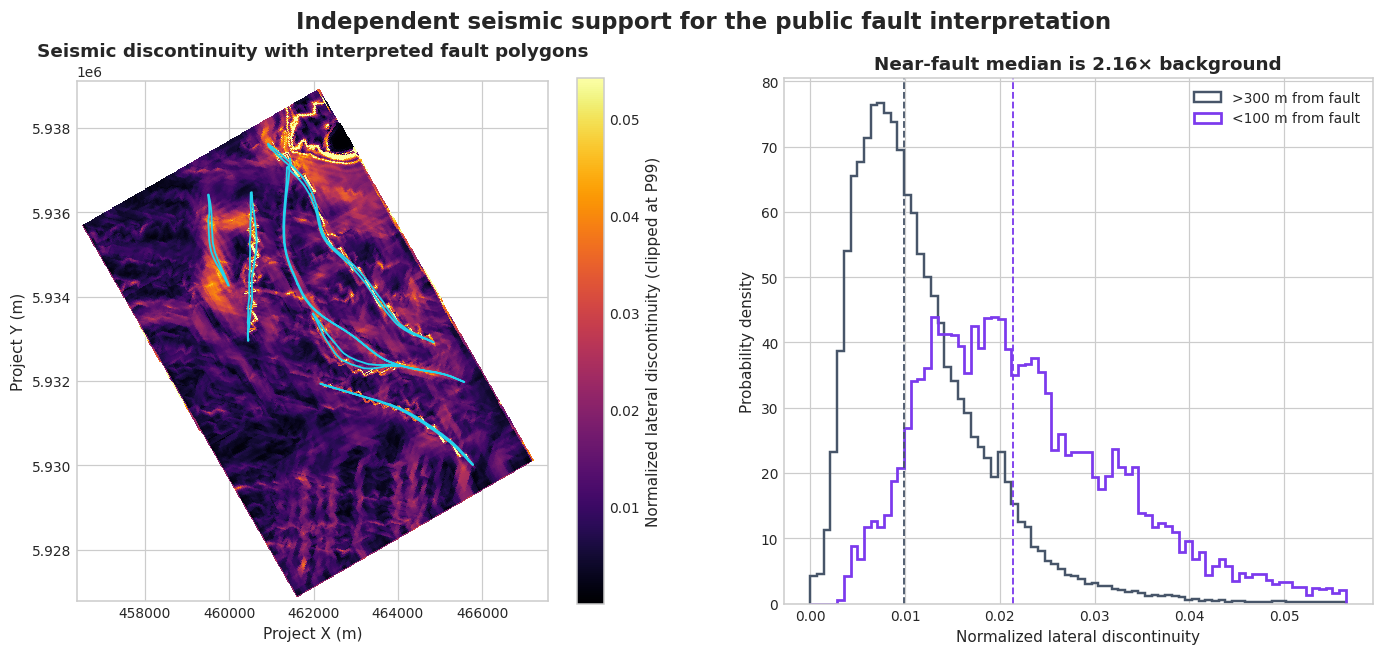

In [22]:
fault_figure, fault_axes = plt.subplots(1, 2, figsize=(15.2, 6.2))
discontinuity_limit = np.quantile(
    normalized_discontinuity[active_trace_mask],
    0.99,
)
fault_map = fault_axes[0].pcolormesh(
    x_grid_m,
    y_grid_m,
    np.ma.array(
        np.clip(normalized_discontinuity, 0.0, discontinuity_limit),
        mask=~active_trace_mask,
    ),
    cmap="inferno",
    shading="auto",
)
for polygon_id, polygon_frame in fault_polygons.dataframe.groupby("POLY_ID"):
    fault_axes[0].plot(
        polygon_frame["X_UTME"],
        polygon_frame["Y_UTMN"],
        color="#22D3EE",
        linewidth=1.2,
    )
fault_axes[0].set_title("Seismic discontinuity with interpreted fault polygons")
fault_axes[0].set_xlabel("Project X (m)")
fault_axes[0].set_ylabel("Project Y (m)")
fault_axes[0].set_aspect("equal")
fault_figure.colorbar(
    fault_map,
    ax=fault_axes[0],
    label="Normalized lateral discontinuity (clipped at P99)",
)

near_values = normalized_discontinuity[near_fault_mask]
background_values = normalized_discontinuity[background_mask]
histogram_limit = np.quantile(
    np.concatenate([near_values, background_values]),
    0.99,
)
fault_axes[1].hist(
    background_values,
    bins=80,
    range=(0.0, histogram_limit),
    density=True,
    histtype="step",
    linewidth=1.6,
    color=COLORS["neutral"],
    label=">300 m from fault",
)
fault_axes[1].hist(
    near_values,
    bins=80,
    range=(0.0, histogram_limit),
    density=True,
    histtype="step",
    linewidth=1.8,
    color=COLORS["uncertainty"],
    label="<100 m from fault",
)
fault_axes[1].axvline(
    background_median,
    color=COLORS["neutral"],
    linestyle="--",
    linewidth=1.2,
)
fault_axes[1].axvline(
    near_fault_median,
    color=COLORS["uncertainty"],
    linestyle="--",
    linewidth=1.2,
)
fault_axes[1].set_title(f"Near-fault median is {fault_support_ratio:.2f}× background")
fault_axes[1].set_xlabel("Normalized lateral discontinuity")
fault_axes[1].set_ylabel("Probability density")
fault_axes[1].legend()

fault_figure.suptitle(
    "Independent seismic support for the public fault interpretation",
    fontsize=15,
    weight="bold",
)
save_figure(fault_figure, "10_fault_discontinuity_support.png")
plt.show()

## 8. Time-to-depth conversion when the input is time-migrated

The executed Reek cube is already in depth. A time-migrated project instead needs an approved
velocity model calibrated to checkshots or VSP data. For vertical propagation,

$$z(t)=\frac{1}{2}\int_0^t v(\tau)\,d\tau$$

The following fully calculated example constructs a smooth interval-velocity profile, generates
sparse noisy checkshots, fits a monotone time-to-depth transform, and measures conversion error.
It is stored under `diagnostics/` and is explicitly **not** the velocity model for the Reek depth
cube.

In [23]:
velocity_depth_m = np.arange(0.0, 2200.0 + 5.0, 5.0)
interval_velocity_m_s = (
    2050.0
    + 0.58 * velocity_depth_m
    + 110.0 * np.tanh((velocity_depth_m - 1350.0) / 260.0)
)
one_way_time_s = cumulative_trapezoid(
    1.0 / interval_velocity_m_s,
    velocity_depth_m,
    initial=0.0,
)
true_twt_s = 2.0 * one_way_time_s

checkshot_depth_m = np.arange(150.0, 2100.0 + 1.0, 150.0)
checkshot_true_twt_s = np.interp(
    checkshot_depth_m,
    velocity_depth_m,
    true_twt_s,
)
checkshot_noise_s = np.array(
    [0.000, 0.001, -0.001, 0.002, -0.001, 0.001, 0.000,
     -0.002, 0.001, 0.000, -0.001, 0.001, 0.000, -0.001]
)
checkshot_observed_twt_s = checkshot_true_twt_s + checkshot_noise_s
time_to_depth_model = PchipInterpolator(
    np.concatenate([[0.0], checkshot_observed_twt_s]),
    np.concatenate([[0.0], checkshot_depth_m]),
)

evaluation_mask = true_twt_s <= checkshot_observed_twt_s.max()
converted_depth_m = time_to_depth_model(true_twt_s[evaluation_mask])
depth_conversion_error_m = converted_depth_m - velocity_depth_m[evaluation_mask]
depth_conversion_rmse_m = float(
    np.sqrt(np.mean(depth_conversion_error_m**2))
)

checkshot_table = pd.DataFrame(
    {
        "depth TVDSS (m)": checkshot_depth_m,
        "true TWT (ms)": 1000.0 * checkshot_true_twt_s,
        "observed TWT (ms)": 1000.0 * checkshot_observed_twt_s,
        "time error (ms)": 1000.0 * checkshot_noise_s,
    }
)
display(checkshot_table.round(2))
print("Illustrative depth-conversion RMSE:", round(depth_conversion_rmse_m, 3), "m")

Illustrative depth-conversion RMSE: 1.116 m


,depth TVDSS (m),true TWT (ms),observed TWT (ms),time error (ms)
0,150.0,151.27,151.27,0.0
1,300.0,296.18,297.18,1.0
2,450.0,435.24,434.24,-1.0
3,600.0,568.90,570.90,2.0
4,750.0,697.51,696.51,-1.0
5,900.0,821.37,822.37,1.0
6,1050.0,940.54,940.54,0.0
7,1200.0,1054.77,1052.77,-2.0
8,1350.0,1163.51,1164.51,1.0
9,1500.0,1266.75,1266.75,0.0


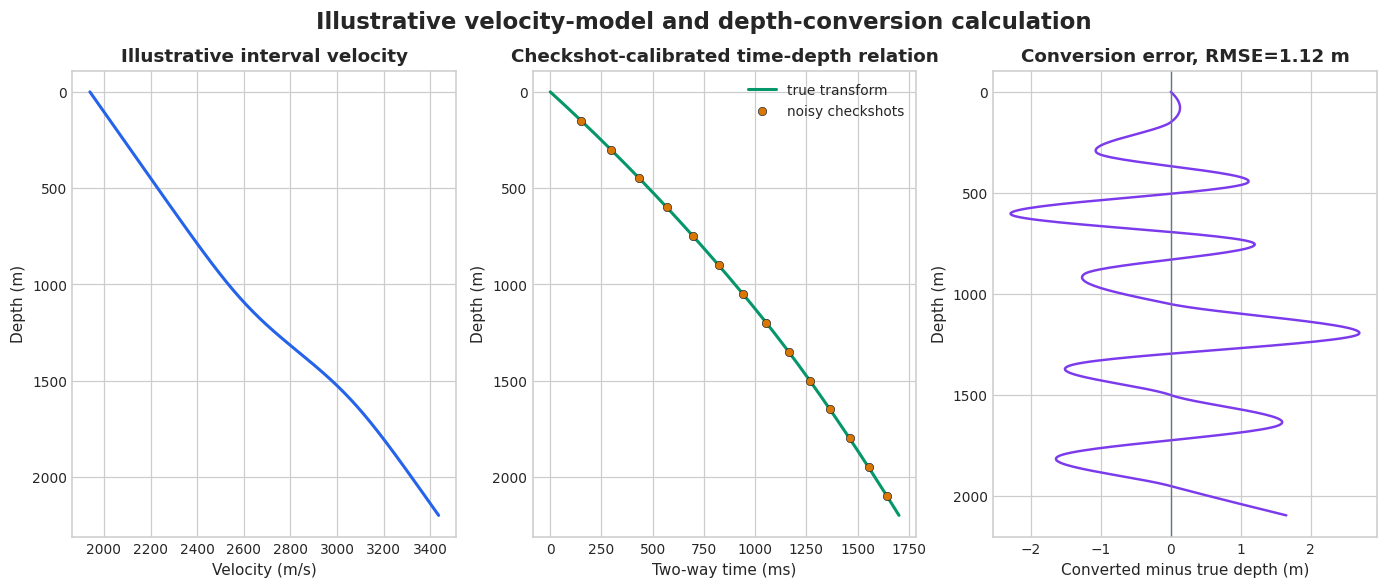

In [24]:
depth_figure, depth_axes = plt.subplots(1, 3, figsize=(15.3, 5.5))

depth_axes[0].plot(
    interval_velocity_m_s,
    velocity_depth_m,
    color=COLORS["processed"],
    linewidth=2.0,
)
depth_axes[0].invert_yaxis()
depth_axes[0].set_title("Illustrative interval velocity")
depth_axes[0].set_xlabel("Velocity (m/s)")
depth_axes[0].set_ylabel("Depth (m)")

depth_axes[1].plot(
    1000.0 * true_twt_s,
    velocity_depth_m,
    color=COLORS["reference"],
    linewidth=2.0,
    label="true transform",
)
depth_axes[1].scatter(
    1000.0 * checkshot_observed_twt_s,
    checkshot_depth_m,
    color=COLORS["input"],
    edgecolor="#111827",
    linewidth=0.4,
    s=30,
    label="noisy checkshots",
    zorder=4,
)
depth_axes[1].invert_yaxis()
depth_axes[1].set_title("Checkshot-calibrated time-depth relation")
depth_axes[1].set_xlabel("Two-way time (ms)")
depth_axes[1].set_ylabel("Depth (m)")
depth_axes[1].legend()

depth_axes[2].plot(
    depth_conversion_error_m,
    velocity_depth_m[evaluation_mask],
    color=COLORS["uncertainty"],
    linewidth=1.6,
)
depth_axes[2].axvline(0.0, color="#64748B", linewidth=0.9)
depth_axes[2].invert_yaxis()
depth_axes[2].set_title(f"Conversion error, RMSE={depth_conversion_rmse_m:.2f} m")
depth_axes[2].set_xlabel("Converted minus true depth (m)")
depth_axes[2].set_ylabel("Depth (m)")

depth_figure.suptitle(
    "Illustrative velocity-model and depth-conversion calculation",
    fontsize=15,
    weight="bold",
)
save_figure(depth_figure, "11_time_to_depth_conversion.png")
plt.show()

## 9. Structural uncertainty realizations for RMS

The withheld-reference residuals provide an empirical error scale for this fixture. Six smooth
correlated realizations are generated with deterministic random seeds. Perturbations taper to
zero at the sparse control nodes and preserve at least 10 m gross thickness.

These are **teaching realizations**, not a calibrated structural-uncertainty model. Production
uncertainty should distinguish picking, mistie, velocity, fault position/throw, depth conversion,
erosion, and structural scenario uncertainty, with correlation ranges justified by the survey
and interpretation workflow.

In [25]:
top_rmse_m = float(
    horizon_metrics_table.loc[
        horizon_metrics_table["horizon"].eq("Top Reek"),
        "RMSE (m)",
    ].iloc[0]
)
base_rmse_m = float(
    horizon_metrics_table.loc[
        horizon_metrics_table["horizon"].eq("Base Reek"),
        "RMSE (m)",
    ].iloc[0]
)

combined_control_mask = top_control_mask | base_control_mask
distance_to_control_cells = distance_transform_edt(~combined_control_mask)
control_taper = np.clip(distance_to_control_cells / 20.0, 0.0, 1.0)
structural_rng = np.random.default_rng(RANDOM_SEED + 17)
number_of_realizations = 6
top_realization_arrays = []
base_realization_arrays = []
top_realization_surfaces = []
base_realization_surfaces = []
grv_rows = []
cell_area_m2 = seismic_cube.xinc * seismic_cube.yinc

for realization_index in range(number_of_realizations):
    regional_field = gaussian_filter(
        structural_rng.normal(size=top_pick_m.shape),
        sigma=12.0,
    )
    regional_values = regional_field[common_horizon_mask]
    regional_field = (
        regional_field - np.mean(regional_values)
    ) / np.std(regional_values)

    thickness_field = gaussian_filter(
        structural_rng.normal(size=top_pick_m.shape),
        sigma=8.0,
    )
    thickness_values = thickness_field[common_horizon_mask]
    thickness_field = (
        thickness_field - np.mean(thickness_values)
    ) / np.std(thickness_values)

    top_realization = (
        top_pick_m
        + regional_field * top_rmse_m * control_taper
    )
    base_realization = (
        base_pick_m
        + regional_field * 0.70 * base_rmse_m * control_taper
        + thickness_field * 4.0 * control_taper
    )
    base_realization = np.maximum(base_realization, top_realization + 10.0)
    top_realization_arrays.append(top_realization)
    base_realization_arrays.append(base_realization)

    top_surface = xtgeo.surface_from_cube(conditioned_cube, 0.0)
    top_surface.values = np.ma.array(top_realization, mask=~common_horizon_mask)
    base_surface = xtgeo.surface_from_cube(conditioned_cube, 0.0)
    base_surface.values = np.ma.array(base_realization, mask=~common_horizon_mask)
    top_realization_surfaces.append(top_surface)
    base_realization_surfaces.append(base_surface)

    thickness_values_m = (
        base_realization[common_horizon_mask]
        - top_realization[common_horizon_mask]
    )
    gross_rock_volume_m3 = float(
        np.sum(thickness_values_m) * cell_area_m2
    )
    grv_rows.append(
        {
            "realization": realization_index,
            "mean top depth (m)": float(np.mean(top_realization[common_horizon_mask])),
            "mean thickness (m)": float(np.mean(thickness_values_m)),
            "GRV (million m3)": gross_rock_volume_m3 / 1.0e6,
        }
    )

top_realization_stack = np.stack(top_realization_arrays)
base_realization_stack = np.stack(base_realization_arrays)
structural_standard_deviation_m = np.std(top_realization_stack, axis=0)
grv_table = pd.DataFrame(grv_rows)
display(grv_table.round(3))
print(
    "GRV P10/P50/P90 (million m3):",
    np.round(np.percentile(grv_table["GRV (million m3)"], [10, 50, 90]), 3),
)

GRV P10/P50/P90 (million m3): [3001.792 3005.382 3007.924]


,realization,mean top depth (m),mean thickness (m),GRV (million m3)
0,0,1687.763,52.906,3007.845
1,1,1687.889,52.835,3003.796
2,2,1688.096,52.764,2999.789
3,3,1687.868,52.876,3006.157
4,4,1687.946,52.849,3004.607
5,5,1687.693,52.909,3008.003


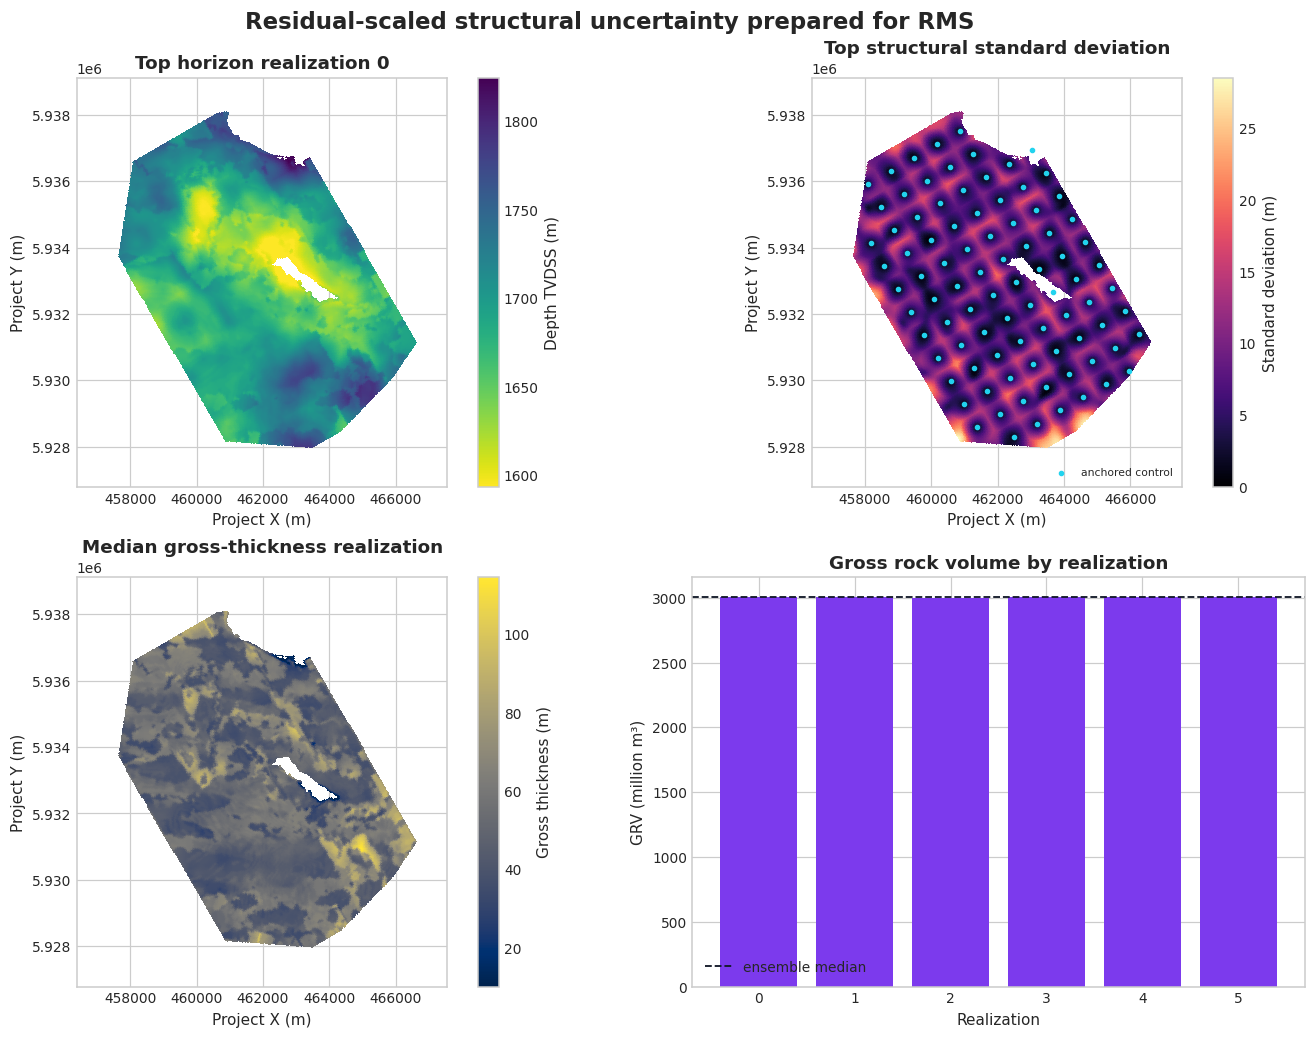

In [26]:
uncertainty_figure, uncertainty_axes = plt.subplots(2, 2, figsize=(15.8, 10.2))

realization_image = draw_xy_surface(
    uncertainty_axes[0, 0],
    top_realization_arrays[0],
    "Top horizon realization 0",
    "viridis_r",
    depth_limits,
)
standard_deviation_image = uncertainty_axes[0, 1].pcolormesh(
    x_grid_m,
    y_grid_m,
    np.ma.array(structural_standard_deviation_m, mask=~common_horizon_mask),
    cmap="magma",
    shading="auto",
)
uncertainty_axes[0, 1].scatter(
    x_grid_m[combined_control_mask],
    y_grid_m[combined_control_mask],
    s=7,
    color="#22D3EE",
    label="anchored control",
)
uncertainty_axes[0, 1].set_title("Top structural standard deviation")
uncertainty_axes[0, 1].set_xlabel("Project X (m)")
uncertainty_axes[0, 1].set_ylabel("Project Y (m)")
uncertainty_axes[0, 1].set_aspect("equal")
uncertainty_axes[0, 1].legend(loc="lower right", fontsize=7)

median_thickness = np.median(
    base_realization_stack - top_realization_stack,
    axis=0,
)
thickness_image = uncertainty_axes[1, 0].pcolormesh(
    x_grid_m,
    y_grid_m,
    np.ma.array(median_thickness, mask=~common_horizon_mask),
    cmap="cividis",
    shading="auto",
)
uncertainty_axes[1, 0].set_title("Median gross-thickness realization")
uncertainty_axes[1, 0].set_xlabel("Project X (m)")
uncertainty_axes[1, 0].set_ylabel("Project Y (m)")
uncertainty_axes[1, 0].set_aspect("equal")

uncertainty_axes[1, 1].bar(
    grv_table["realization"].astype(str),
    grv_table["GRV (million m3)"],
    color=COLORS["uncertainty"],
)
uncertainty_axes[1, 1].axhline(
    grv_table["GRV (million m3)"].median(),
    color="#111827",
    linestyle="--",
    linewidth=1.2,
    label="ensemble median",
)
uncertainty_axes[1, 1].set_title("Gross rock volume by realization")
uncertainty_axes[1, 1].set_xlabel("Realization")
uncertainty_axes[1, 1].set_ylabel("GRV (million m³)")
uncertainty_axes[1, 1].legend()

uncertainty_figure.colorbar(
    realization_image,
    ax=uncertainty_axes[0, 0],
    label="Depth TVDSS (m)",
)
uncertainty_figure.colorbar(
    standard_deviation_image,
    ax=uncertainty_axes[0, 1],
    label="Standard deviation (m)",
)
uncertainty_figure.colorbar(
    thickness_image,
    ax=uncertainty_axes[1, 0],
    label="Gross thickness (m)",
)
uncertainty_figure.suptitle(
    "Residual-scaled structural uncertainty prepared for RMS",
    fontsize=15,
    weight="bold",
)
uncertainty_figure.subplots_adjust(top=0.92, hspace=0.22, wspace=0.20)
save_figure(uncertainty_figure, "12_structural_uncertainty.png")
plt.show()

## 10. Interval seismic attributes and a property-model acceptance gate

RMS can use seismic attributes as trends or secondary variables, but a visually attractive map is
not evidence that it predicts reservoir properties. The code calculates RMS amplitude, mean
absolute amplitude, maximum negative amplitude, variance, and thickness between the interpreted
horizons.

For a candidate linear porosity relationship,

$$\hat{\phi}=\beta_0+\sum_{j=1}^{p}\beta_j x_j$$

ridge regularization is applied to the standardized features. Leave-one-well-out prediction is
compared with a training-mean baseline. The seismic trend is accepted only if it reduces RMSE by
at least 10% **and** achieves correlation of at least 0.5. A failed trend is kept only as a
diagnostic and is excluded from the RMS import manifest.

In [27]:
seismic_attributes = conditioned_cube.compute_attributes_in_window(
    top_interpreted_surface,
    base_interpreted_surface,
    ndiv=12,
    interpolation="linear",
    minimum_thickness=10.0,
)
rms_amplitude_surface = seismic_attributes["rms"]
mean_absolute_surface = seismic_attributes["meanabs"]
maximum_negative_surface = seismic_attributes["maxneg"]
variance_surface = seismic_attributes["var"]

attribute_rows = []
for attribute_name, attribute_surface in [
    ("RMS amplitude", rms_amplitude_surface),
    ("mean absolute amplitude", mean_absolute_surface),
    ("maximum negative amplitude", maximum_negative_surface),
    ("amplitude variance", variance_surface),
    ("gross thickness", gross_thickness_surface),
]:
    values = attribute_surface.values.compressed()
    attribute_rows.append(
        {
            "attribute": attribute_name,
            "valid nodes": len(values),
            "minimum": float(np.min(values)),
            "median": float(np.median(values)),
            "P95": float(np.percentile(values, 95.0)),
            "maximum": float(np.max(values)),
        }
    )

attribute_summary = pd.DataFrame(attribute_rows)
display(attribute_summary.round(5))

,attribute,valid nodes,minimum,median,P95,maximum
0,RMS amplitude,90826,0.00003,0.09096,0.16697,0.32398
1,mean absolute amplitude,90826,0.00001,0.07491,0.14744,0.27433
2,maximum negative amplitude,90812,-0.84753,-0.15507,-0.06528,-0.00000
3,amplitude variance,90826,0.00000,0.00817,0.02766,0.09565
4,gross thickness,90826,10.04717,51.28838,77.07378,116.13129


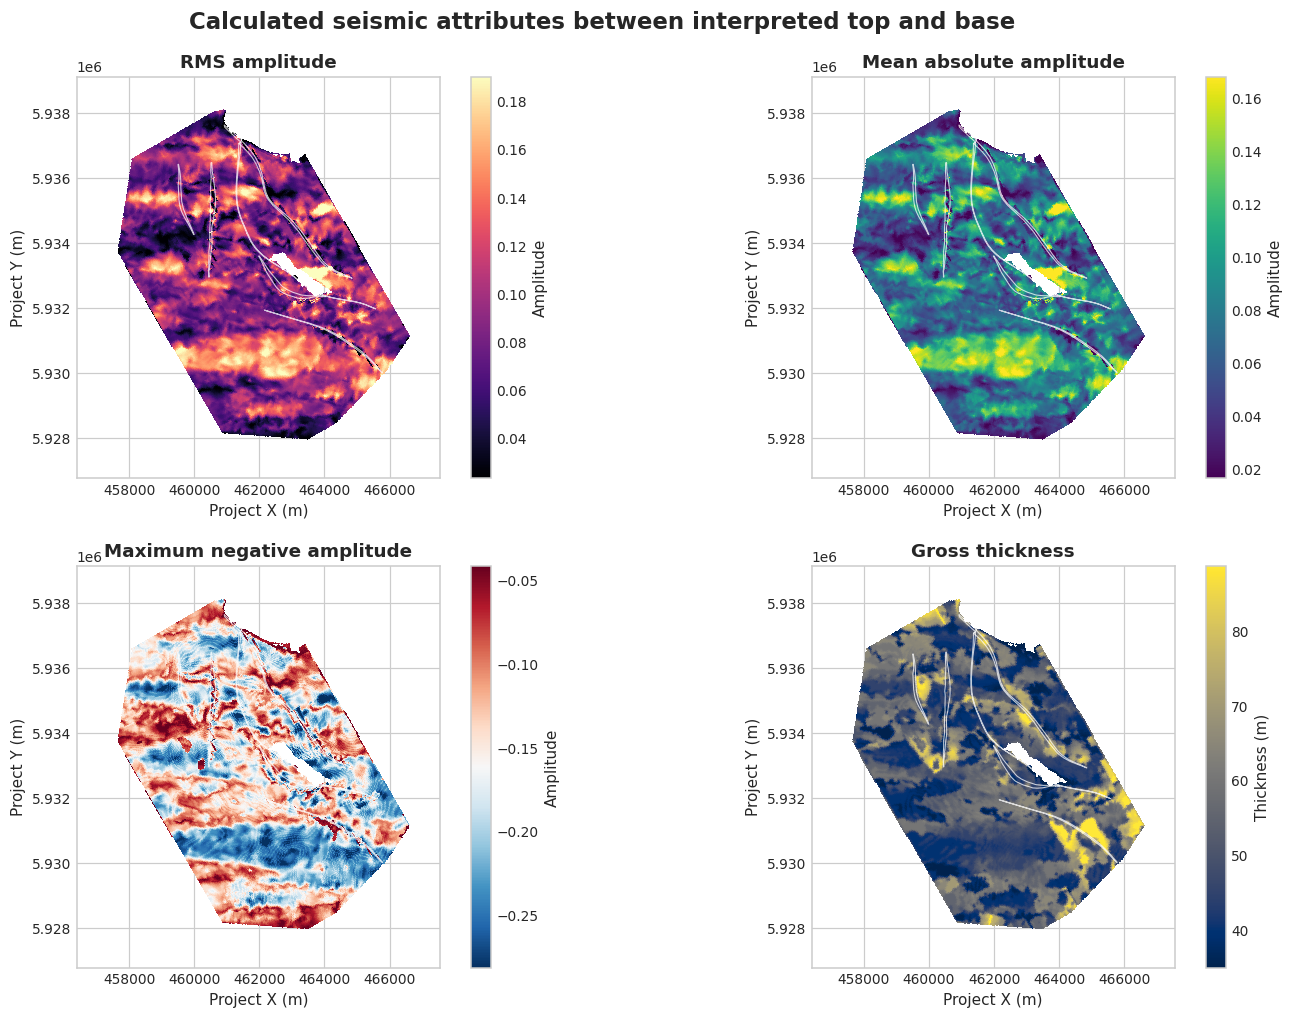

In [28]:
attribute_figure, attribute_axes = plt.subplots(2, 2, figsize=(15.8, 10.0))

attribute_specs = [
    (rms_amplitude_surface, "RMS amplitude", "magma", "Amplitude"),
    (
        mean_absolute_surface,
        "Mean absolute amplitude",
        "viridis",
        "Amplitude",
    ),
    (
        maximum_negative_surface,
        "Maximum negative amplitude",
        "RdBu_r",
        "Amplitude",
    ),
    (
        gross_thickness_surface,
        "Gross thickness",
        "cividis",
        "Thickness (m)",
    ),
]

for axis, (surface, title, colour_map, label) in zip(
    attribute_axes.ravel(),
    attribute_specs,
):
    values = surface.values
    lower_limit = float(np.percentile(values.compressed(), 1.0))
    upper_limit = float(np.percentile(values.compressed(), 99.0))
    attribute_image = axis.pcolormesh(
        x_grid_m,
        y_grid_m,
        np.ma.clip(values, lower_limit, upper_limit),
        cmap=colour_map,
        shading="auto",
        vmin=lower_limit,
        vmax=upper_limit,
    )
    for polygon_id, polygon_frame in fault_polygons.dataframe.groupby("POLY_ID"):
        axis.plot(
            polygon_frame["X_UTME"],
            polygon_frame["Y_UTMN"],
            color="white",
            linewidth=0.7,
            alpha=0.75,
        )
    axis.set_title(title)
    axis.set_xlabel("Project X (m)")
    axis.set_ylabel("Project Y (m)")
    axis.set_aspect("equal")
    attribute_figure.colorbar(attribute_image, ax=axis, label=label)

attribute_figure.suptitle(
    "Calculated seismic attributes between interpreted top and base",
    fontsize=15,
    weight="bold",
)
attribute_figure.subplots_adjust(top=0.92, hspace=0.22, wspace=0.20)
save_figure(attribute_figure, "13_interval_seismic_attributes.png")
plt.show()

In [29]:
def surface_value_at_xy(surface, x_value_m, y_value_m):
    return float(surface.get_value_from_xy((x_value_m, y_value_m)))


calibration_rows = []
for _, summary_row in well_summary.iterrows():
    x_value_m = float(summary_row["midpoint X (m)"])
    y_value_m = float(summary_row["midpoint Y (m)"])
    calibration_rows.append(
        {
            "well": summary_row["well"],
            "measured mean porosity": summary_row["mean porosity (-)"],
            "RMS amplitude": surface_value_at_xy(
                rms_amplitude_surface,
                x_value_m,
                y_value_m,
            ),
            "mean absolute amplitude": surface_value_at_xy(
                mean_absolute_surface,
                x_value_m,
                y_value_m,
            ),
            "top depth (m)": surface_value_at_xy(
                top_interpreted_surface,
                x_value_m,
                y_value_m,
            ),
            "X (m)": x_value_m,
            "Y (m)": y_value_m,
        }
    )

porosity_calibration = pd.DataFrame(calibration_rows)


def leave_one_out_mean(target):
    predictions = []
    for holdout_index in range(len(target)):
        training_mask = np.arange(len(target)) != holdout_index
        predictions.append(float(np.mean(target[training_mask])))
    return np.asarray(predictions)


def leave_one_out_ridge(features, target, alpha):
    predictions = []
    for holdout_index in range(len(target)):
        training_mask = np.arange(len(target)) != holdout_index
        training_features = features[training_mask]
        feature_mean = np.mean(training_features, axis=0)
        feature_scale = np.std(training_features, axis=0)
        feature_scale = np.where(feature_scale > 0.0, feature_scale, 1.0)
        standardized_training = (
            training_features - feature_mean
        ) / feature_scale
        standardized_holdout = (
            features[holdout_index] - feature_mean
        ) / feature_scale
        design = np.column_stack(
            [np.ones(np.sum(training_mask)), standardized_training]
        )
        regularization = np.diag([0.0] + [alpha] * features.shape[1])
        coefficients = np.linalg.solve(
            design.T @ design + regularization,
            design.T @ target[training_mask],
        )
        prediction = np.concatenate([[1.0], standardized_holdout]) @ coefficients
        predictions.append(float(prediction))
    return np.asarray(predictions)


porosity_target = porosity_calibration["measured mean porosity"].to_numpy()
baseline_predictions = leave_one_out_mean(porosity_target)
single_feature_values = porosity_calibration[["mean absolute amplitude"]].to_numpy()
single_feature_predictions = leave_one_out_ridge(
    single_feature_values,
    porosity_target,
    alpha=5.0,
)
multi_feature_names = ["RMS amplitude", "mean absolute amplitude", "top depth (m)"]
multi_feature_values = porosity_calibration[multi_feature_names].to_numpy()
multi_feature_predictions = leave_one_out_ridge(
    multi_feature_values,
    porosity_target,
    alpha=20.0,
)


def prediction_metrics(name, predictions):
    residuals = predictions - porosity_target
    return {
        "model": name,
        "LOO RMSE (porosity fraction)": float(np.sqrt(np.mean(residuals**2))),
        "LOO MAE (porosity fraction)": float(np.mean(np.abs(residuals))),
        "LOO correlation": float(np.corrcoef(predictions, porosity_target)[0, 1]),
    }


porosity_model_metrics = pd.DataFrame(
    [
        prediction_metrics("training-mean baseline", baseline_predictions),
        prediction_metrics("mean-absolute-amplitude ridge", single_feature_predictions),
        prediction_metrics("three-feature ridge", multi_feature_predictions),
    ]
)
baseline_rmse = float(
    porosity_model_metrics.loc[
        porosity_model_metrics["model"].eq("training-mean baseline"),
        "LOO RMSE (porosity fraction)",
    ].iloc[0]
)
candidate_rmse = float(
    porosity_model_metrics.loc[
        porosity_model_metrics["model"].eq("mean-absolute-amplitude ridge"),
        "LOO RMSE (porosity fraction)",
    ].iloc[0]
)
candidate_correlation = float(
    porosity_model_metrics.loc[
        porosity_model_metrics["model"].eq("mean-absolute-amplitude ridge"),
        "LOO correlation",
    ].iloc[0]
)
porosity_model_accepted = bool(
    candidate_rmse <= 0.90 * baseline_rmse
    and candidate_correlation >= 0.50
)

full_feature_mean = np.mean(single_feature_values, axis=0)
full_feature_scale = np.std(single_feature_values, axis=0)
standardized_features = (
    single_feature_values - full_feature_mean
) / full_feature_scale
full_design = np.column_stack(
    [np.ones(len(porosity_target)), standardized_features]
)
full_regularization = np.diag([0.0, 5.0])
full_coefficients = np.linalg.solve(
    full_design.T @ full_design + full_regularization,
    full_design.T @ porosity_target,
)
mean_absolute_array = np.asarray(mean_absolute_surface.values)
diagnostic_standardized = (
    mean_absolute_array - full_feature_mean[0]
) / full_feature_scale[0]
diagnostic_porosity_array = np.clip(
    full_coefficients[0] + full_coefficients[1] * diagnostic_standardized,
    0.05,
    0.35,
)
diagnostic_porosity_surface = xtgeo.surface_from_cube(conditioned_cube, 0.0)
diagnostic_porosity_surface.values = np.ma.array(
    diagnostic_porosity_array,
    mask=~common_horizon_mask,
)

porosity_calibration["LOO baseline prediction"] = baseline_predictions
porosity_calibration["LOO seismic prediction"] = single_feature_predictions
display(porosity_model_metrics.round(5))
print("Seismic porosity trend accepted for RMS property modelling:", porosity_model_accepted)

Seismic porosity trend accepted for RMS property modelling: False


,model,LOO RMSE (porosity fraction),LOO MAE (porosity fraction),LOO correlation
0,training-mean baseline,0.02745,0.02246,-1.00000
1,mean-absolute-amplitude ridge,0.02780,0.02302,-0.28817
2,three-feature ridge,0.02773,0.02259,-0.35255


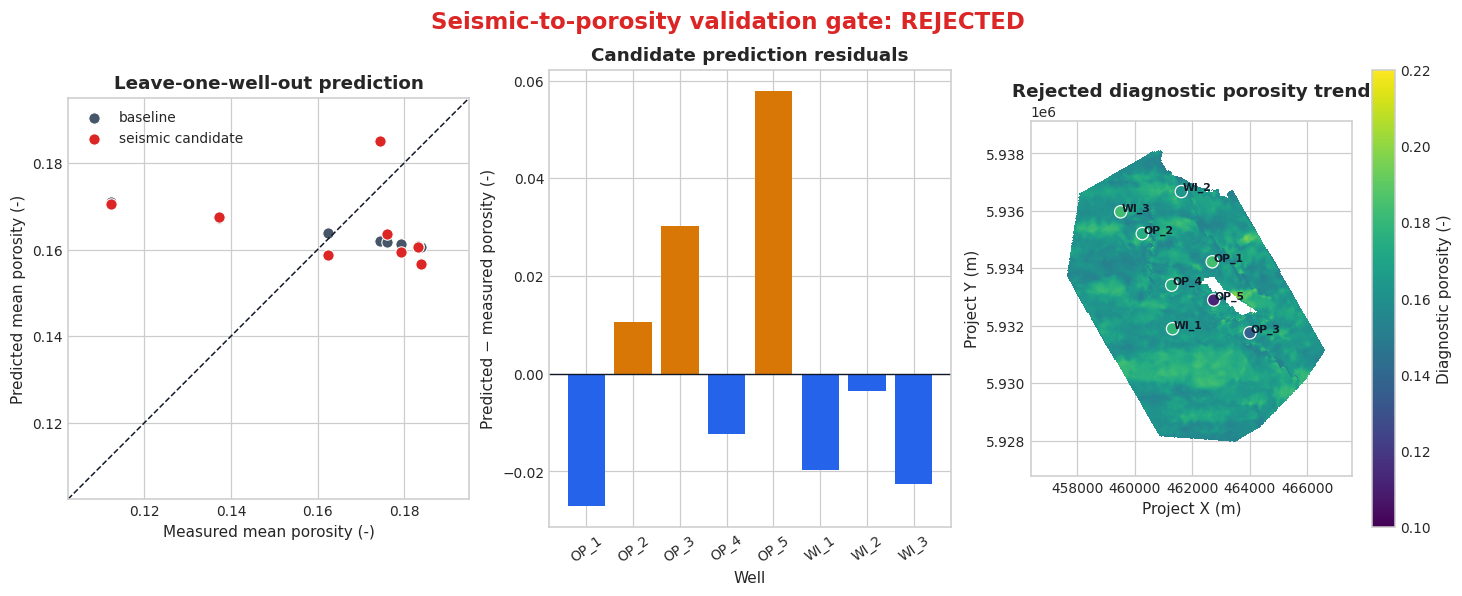

In [30]:
calibration_figure, calibration_axes = plt.subplots(1, 3, figsize=(16.0, 5.4))

porosity_limits = (
    min(porosity_target.min(), single_feature_predictions.min()) - 0.01,
    max(porosity_target.max(), single_feature_predictions.max()) + 0.01,
)
calibration_axes[0].scatter(
    porosity_target,
    baseline_predictions,
    s=55,
    color=COLORS["neutral"],
    edgecolor="white",
    linewidth=0.7,
    label="baseline",
)
calibration_axes[0].scatter(
    porosity_target,
    single_feature_predictions,
    s=55,
    color=COLORS["rejected"],
    edgecolor="white",
    linewidth=0.7,
    label="seismic candidate",
)
calibration_axes[0].plot(
    porosity_limits,
    porosity_limits,
    color="#111827",
    linestyle="--",
    linewidth=1.0,
)
calibration_axes[0].set_xlim(porosity_limits)
calibration_axes[0].set_ylim(porosity_limits)
calibration_axes[0].set_aspect("equal")
calibration_axes[0].set_title("Leave-one-well-out prediction")
calibration_axes[0].set_xlabel("Measured mean porosity (-)")
calibration_axes[0].set_ylabel("Predicted mean porosity (-)")
calibration_axes[0].legend()

residual_values = single_feature_predictions - porosity_target
calibration_axes[1].bar(
    porosity_calibration["well"],
    residual_values,
    color=np.where(
        residual_values >= 0.0,
        COLORS["input"],
        COLORS["processed"],
    ),
)
calibration_axes[1].axhline(0.0, color="#111827", linewidth=0.9)
calibration_axes[1].set_title("Candidate prediction residuals")
calibration_axes[1].set_xlabel("Well")
calibration_axes[1].set_ylabel("Predicted − measured porosity (-)")
calibration_axes[1].tick_params(axis="x", rotation=35)

diagnostic_image = calibration_axes[2].pcolormesh(
    x_grid_m,
    y_grid_m,
    diagnostic_porosity_surface.values,
    cmap="viridis",
    vmin=0.10,
    vmax=0.22,
    shading="auto",
)
calibration_axes[2].scatter(
    porosity_calibration["X (m)"],
    porosity_calibration["Y (m)"],
    c=porosity_target,
    cmap="viridis",
    vmin=0.10,
    vmax=0.22,
    s=65,
    edgecolor="white",
    linewidth=0.8,
)
for _, row in porosity_calibration.iterrows():
    calibration_axes[2].text(
        row["X (m)"] + 35.0,
        row["Y (m)"] + 35.0,
        row["well"],
        fontsize=7,
        color="#111827",
        weight="bold",
    )
calibration_axes[2].set_title("Rejected diagnostic porosity trend")
calibration_axes[2].set_xlabel("Project X (m)")
calibration_axes[2].set_ylabel("Project Y (m)")
calibration_axes[2].set_aspect("equal")
calibration_figure.colorbar(
    diagnostic_image,
    ax=calibration_axes[2],
    label="Diagnostic porosity (-)",
)

acceptance_text = "REJECTED" if not porosity_model_accepted else "ACCEPTED"
calibration_figure.suptitle(
    f"Seismic-to-porosity validation gate: {acceptance_text}",
    fontsize=15,
    weight="bold",
    color=COLORS["rejected"] if not porosity_model_accepted else COLORS["reference"],
)
save_figure(calibration_figure, "14_porosity_trend_acceptance_gate.png")
plt.show()

### Interpretation of the property gate

The seismic candidate is expected to fail for this fixture: its leave-one-well-out skill does not
clear the declared improvement and correlation thresholds. That is a useful engineering result.
The package exports the interval amplitude maps and well summaries so RMS users can investigate
facies-conditioned or nonlinear relationships, but it does **not** label the diagnostic map as an
accepted porosity trend.

This prevents a common failure mode: importing a smooth, visually convincing attribute as a
geological property without proving predictive value at blind wells.

## 11. Build the RMS-ready import package

The package is organized in the order normally used to initialize an RMS interpretation or
geomodelling project:

| Order | Object | Export format | Purpose |
|---|---|---|---|
| 1 | conditioned seismic | SEG-Y | interpretation volume |
| 2 | top/base horizons | IRAP/RMS ASCII | structural framework |
| 3 | fault polygons | RMS polygon ASCII | fault framework |
| 4 | wells and logs | RMS well ASCII + LAS | trajectories and properties |
| 5 | seismic attributes | IRAP/RMS ASCII | candidate secondary data |
| 6 | structural realizations | IRAP/RMS ASCII | uncertainty cases |
| 7 | contracts and checksums | JSON/CSV/Markdown | governance and automation |

The diagnostic porosity trend is placed under `diagnostics/` and marked rejected. It is not in the
approved RMS import action list.

In [31]:
package_subdirectories = [
    "seismic",
    "surfaces",
    "faults",
    "wells",
    "attributes",
    "uncertainty",
    "diagnostics",
    "contracts",
]
for subdirectory in package_subdirectories:
    (PACKAGE_DIRECTORY / subdirectory).mkdir(parents=True, exist_ok=True)

conditioned_segy_path = PACKAGE_DIRECTORY / "seismic" / "reek_depth_stack_qc.segy"
conditioned_cube.to_file(conditioned_segy_path, fformat="segy")

top_surface_path = PACKAGE_DIRECTORY / "surfaces" / "top_reek_interpreted.fgr"
base_surface_path = PACKAGE_DIRECTORY / "surfaces" / "base_reek_interpreted.fgr"
thickness_surface_path = PACKAGE_DIRECTORY / "surfaces" / "reek_gross_thickness.fgr"
top_interpreted_surface.to_file(top_surface_path, fformat="irap_ascii")
base_interpreted_surface.to_file(base_surface_path, fformat="irap_ascii")
gross_thickness_surface.to_file(thickness_surface_path, fformat="irap_ascii")

fault_output_path = PACKAGE_DIRECTORY / "faults" / "top_reek_faults.pol"
fault_polygons.to_file(fault_output_path, fformat="pol")

well_export_rows = []
for well_name, well in wells.items():
    rms_well_path = PACKAGE_DIRECTORY / "wells" / f"{well_name}.w"
    well.to_file(rms_well_path, fformat="rms_ascii")
    export_row = {
        "well": well_name,
        "RMS well file": rms_well_path.name,
        "LAS log file": None,
    }
    well_frame = well.dataframe.copy()
    if "Zonelog" in well_frame:
        trajectory_delta = np.sqrt(
            np.diff(well_frame["X_UTME"], prepend=well_frame["X_UTME"].iloc[0]) ** 2
            + np.diff(well_frame["Y_UTMN"], prepend=well_frame["Y_UTMN"].iloc[0]) ** 2
            + np.diff(well_frame["Z_TVDSS"], prepend=well_frame["Z_TVDSS"].iloc[0]) ** 2
        )
        measured_depth_m = np.cumsum(trajectory_delta)
        las_file = lasio.LASFile()
        las_file.well.WELL.value = well_name
        las_file.well.NULL.value = -999.25
        las_file.append_curve("DEPT", measured_depth_m, unit="m", descr="Measured depth")
        las_file.append_curve(
            "TVDSS",
            well_frame["Z_TVDSS"].to_numpy(),
            unit="m",
            descr="True vertical depth subsea",
        )
        las_file.append_curve(
            "PHIT",
            well_frame["Poro"].fillna(-999.25).to_numpy(),
            unit="v/v",
            descr="Public Reek total porosity",
        )
        las_file.append_curve(
            "PERM",
            well_frame["Perm"].fillna(-999.25).to_numpy(),
            unit="mD",
            descr="Public Reek permeability",
        )
        las_file.append_curve(
            "FACIES",
            well_frame["Facies"].fillna(-999.25).to_numpy(),
            unit="code",
            descr="Public Reek facies code",
        )
        las_file.append_curve(
            "ZONE",
            well_frame["Zonelog"].fillna(-999.25).to_numpy(),
            unit="code",
            descr="Public Reek zone code",
        )
        las_path = PACKAGE_DIRECTORY / "wells" / f"{well_name}.las"
        las_file.write(str(las_path), version=2.0)
        export_row["LAS log file"] = las_path.name
    well_export_rows.append(export_row)

well_tops_path = PACKAGE_DIRECTORY / "wells" / "well_tops.csv"
well_summary.to_csv(well_tops_path, index=False)

control_rows = []
for horizon_name, reference_surface, control_mask in [
    ("Top Reek", top_reference_cube, top_control_mask),
    ("Base Reek", base_reference_cube, base_control_mask),
]:
    control_values = np.asarray(reference_surface.values)[control_mask]
    for x_value, y_value, z_value in zip(
        x_grid_m[control_mask],
        y_grid_m[control_mask],
        control_values,
    ):
        control_rows.append(
            {
                "horizon": horizon_name,
                "X_m": x_value,
                "Y_m": y_value,
                "Z_TVDSS_m": z_value,
            }
        )
control_points_path = PACKAGE_DIRECTORY / "surfaces" / "horizon_control_points.csv"
pd.DataFrame(control_rows).to_csv(control_points_path, index=False)

attribute_exports = [
    (
        rms_amplitude_surface,
        PACKAGE_DIRECTORY / "attributes" / "reek_interval_rms_amplitude.fgr",
    ),
    (
        mean_absolute_surface,
        PACKAGE_DIRECTORY / "attributes" / "reek_interval_mean_abs_amplitude.fgr",
    ),
    (
        discontinuity_surface,
        PACKAGE_DIRECTORY / "attributes" / "reek_lateral_discontinuity.fgr",
    ),
]
for attribute_surface, attribute_path in attribute_exports:
    attribute_surface.to_file(attribute_path, fformat="irap_ascii")

diagnostic_porosity_path = (
    PACKAGE_DIRECTORY / "diagnostics" / "rejected_seismic_porosity_trend.fgr"
)
diagnostic_porosity_surface.to_file(
    diagnostic_porosity_path,
    fformat="irap_ascii",
)
porosity_model_metrics.to_csv(
    PACKAGE_DIRECTORY / "diagnostics" / "porosity_model_validation.csv",
    index=False,
)
checkshot_table.to_csv(
    PACKAGE_DIRECTORY / "diagnostics" / "illustrative_checkshots.csv",
    index=False,
)

for realization_index, (top_surface, base_surface) in enumerate(
    zip(top_realization_surfaces, base_realization_surfaces)
):
    top_surface.to_file(
        PACKAGE_DIRECTORY
        / "uncertainty"
        / f"top_reek_realization_{realization_index:03d}.fgr",
        fformat="irap_ascii",
    )
    base_surface.to_file(
        PACKAGE_DIRECTORY
        / "uncertainty"
        / f"base_reek_realization_{realization_index:03d}.fgr",
        fformat="irap_ascii",
    )

input_inventory.to_csv(
    PACKAGE_DIRECTORY / "contracts" / "public_input_inventory.csv",
    index=False,
)
horizon_metrics_table.to_csv(
    PACKAGE_DIRECTORY / "contracts" / "horizon_validation.csv",
    index=False,
)
grv_table.to_csv(
    PACKAGE_DIRECTORY / "contracts" / "structural_realizations.csv",
    index=False,
)

rms_worker_request = {
    "schema_version": "1.0",
    "request_id": "reek-seismic-to-rms-20260901",
    "application": "RMS",
    "data_domain": "depth",
    "coordinate_reference": {
        "horizontal": "project-local Cartesian",
        "horizontal_unit": "m",
        "vertical_reference": "TVDSS",
        "vertical_unit": "m",
        "positive_vertical_direction": "down",
        "epsg": None,
        "approval_required_before_production_use": True,
    },
    "actions": [
        {
            "order": 1,
            "operation": "import_seismic_cube",
            "source": "seismic/reek_depth_stack_qc.segy",
            "target": "Reek_Depth_Stack_QC",
        },
        {
            "order": 2,
            "operation": "import_horizon_surfaces",
            "sources": [
                "surfaces/top_reek_interpreted.fgr",
                "surfaces/base_reek_interpreted.fgr",
            ],
            "category": "Seismic_Interpretation",
        },
        {
            "order": 3,
            "operation": "import_fault_polygons",
            "source": "faults/top_reek_faults.pol",
        },
        {
            "order": 4,
            "operation": "import_wells_and_logs",
            "source_globs": ["wells/*.w", "wells/*.las"],
        },
        {
            "order": 5,
            "operation": "import_secondary_attribute_maps",
            "sources": [
                "attributes/reek_interval_rms_amplitude.fgr",
                "attributes/reek_interval_mean_abs_amplitude.fgr",
                "attributes/reek_lateral_discontinuity.fgr",
            ],
        },
        {
            "order": 6,
            "operation": "build_structural_and_geological_model",
            "human_review_gate": True,
        },
        {
            "order": 7,
            "operation": "export_roff_handoff",
            "expected_outputs": [
                "reek_geological_grid.roff",
                "reek_geological_grid--poro.roff",
                "reek_geological_grid--perm.roff",
                "reek_geological_grid--facies.roff",
                "rms_export_manifest.json",
            ],
        },
    ],
    "excluded_from_approved_imports": [
        {
            "path": "diagnostics/rejected_seismic_porosity_trend.fgr",
            "reason": "Leave-one-well-out validation did not pass the acceptance gate.",
        }
    ],
    "guardrails": {
        "write_mode": "new objects only",
        "overwrite_existing_objects": False,
        "require_human_approval_before_commit": True,
        "require_checksum_verification": True,
        "require_roundtrip_validation": True,
    },
}
worker_request_path = PACKAGE_DIRECTORY / "contracts" / "rms_worker_request.json"
worker_request_path.write_text(
    json.dumps(rms_worker_request, indent=2),
    encoding="utf-8",
)

readme_text = '''# Reek seismic-to-RMS teaching package

Import in the order specified by `contracts/rms_worker_request.json`.

Important boundaries:

- The public Reek fixture is synthetic and licensed under LGPL v3.0.
- Coordinates are project-local metres; no authoritative EPSG code is claimed.
- The SEG-Y volume is already in depth.
- The porosity trend under `diagnostics/` failed blind-well validation and is excluded.
- A licensed RMS user or governed worker must review and approve all project writes.
- RMS should export ROFF files plus a checksum manifest for the downstream notebook.
'''
(PACKAGE_DIRECTORY / "README_RMS_IMPORT.md").write_text(
    readme_text,
    encoding="utf-8",
)


def build_package_manifest(root_directory):
    rows = []
    for file_path in sorted(root_directory.rglob("*")):
        if file_path.is_file() and file_path.name != "rms_import_manifest.json":
            rows.append(
                {
                    "path": file_path.relative_to(root_directory).as_posix(),
                    "bytes": file_path.stat().st_size,
                    "sha256": sha256_file(file_path),
                }
            )
    return rows


package_files = build_package_manifest(PACKAGE_DIRECTORY)
rms_import_manifest = {
    "schema_version": "1.0",
    "dataset": "Public synthetic Reek seismic-to-RMS teaching package",
    "source_repository": "equinor/xtgeo-testdata",
    "source_commit": DATA_COMMIT,
    "source_license": DATA_LICENSE,
    "domain": "depth",
    "coordinate_reference": rms_worker_request["coordinate_reference"],
    "porosity_trend_status": "rejected",
    "files": package_files,
}
manifest_path = PACKAGE_DIRECTORY / "contracts" / "rms_import_manifest.json"
manifest_path.write_text(
    json.dumps(rms_import_manifest, indent=2),
    encoding="utf-8",
)

zip_path = Path(
    shutil.make_archive(
        str(OUTPUT_DIRECTORY / "reek_seismic_to_rms_inputs"),
        "zip",
        root_dir=PACKAGE_DIRECTORY,
    )
)

package_inventory = pd.DataFrame(
    build_package_manifest(PACKAGE_DIRECTORY)
)
package_inventory["size (MB)"] = package_inventory["bytes"] / 1.0e6
display(package_inventory[["path", "size (MB)", "sha256"]].round({"size (MB)": 3}))
print("Package ZIP:", zip_path.relative_to(Path.cwd()))
print("Package ZIP size (MB):", round(zip_path.stat().st_size / 1.0e6, 3))
print("Package ZIP SHA-256:", sha256_file(zip_path))

Package ZIP: seismic_to_rms_outputs/reek_seismic_to_rms_inputs.zip
Package ZIP size (MB): 30.811
Package ZIP SHA-256: 7bbebaa704f1716a66ef46d2947a1be0539ba2666dc11ff449b0121c1f608bea


,path,size (MB),sha256
0,README_RMS_IMPORT.md,0.001,932d36008e9819238ed2064d4bc2ee32623064a819c570...
1,attributes/reek_interval_mean_abs_amplitude.fgr,1.169,eeba28a44c7288b44d0d0a75765bbb68a721ad6ac1038f...
2,attributes/reek_interval_rms_amplitude.fgr,1.169,6659a9d32862de5bb0db12096c692410b624569ac99e89...
3,attributes/reek_lateral_discontinuity.fgr,1.080,c00217a9955112b134101a35a52367354315b5002ac47a...
4,contracts/horizon_validation.csv,0.000,ab46a4144ff4561d1e87a0cbfdc3809c84e0e0d84c0e38...
5,contracts/public_input_inventory.csv,0.001,4a9b3acb58f4a4e03ffc06a4c10dce0cc63fbf8ed8d392...
6,contracts/rms_worker_request.json,0.002,a88c09d6913a31c8d4b458865309b43ac3388eafb9e8c5...
7,contracts/structural_realizations.csv,0.000,170d3b57dcf51277db7f4769f0ef873af7baa08294b490...
8,diagnostics/illustrative_checkshots.csv,0.001,cd6e2afbcaebe69f61e9f19382018fc36f5cf2be4d5d6f...
9,diagnostics/porosity_model_validation.csv,0.000,6b2928a526d4e66e74132af346c00e25c3e95adab157fb...


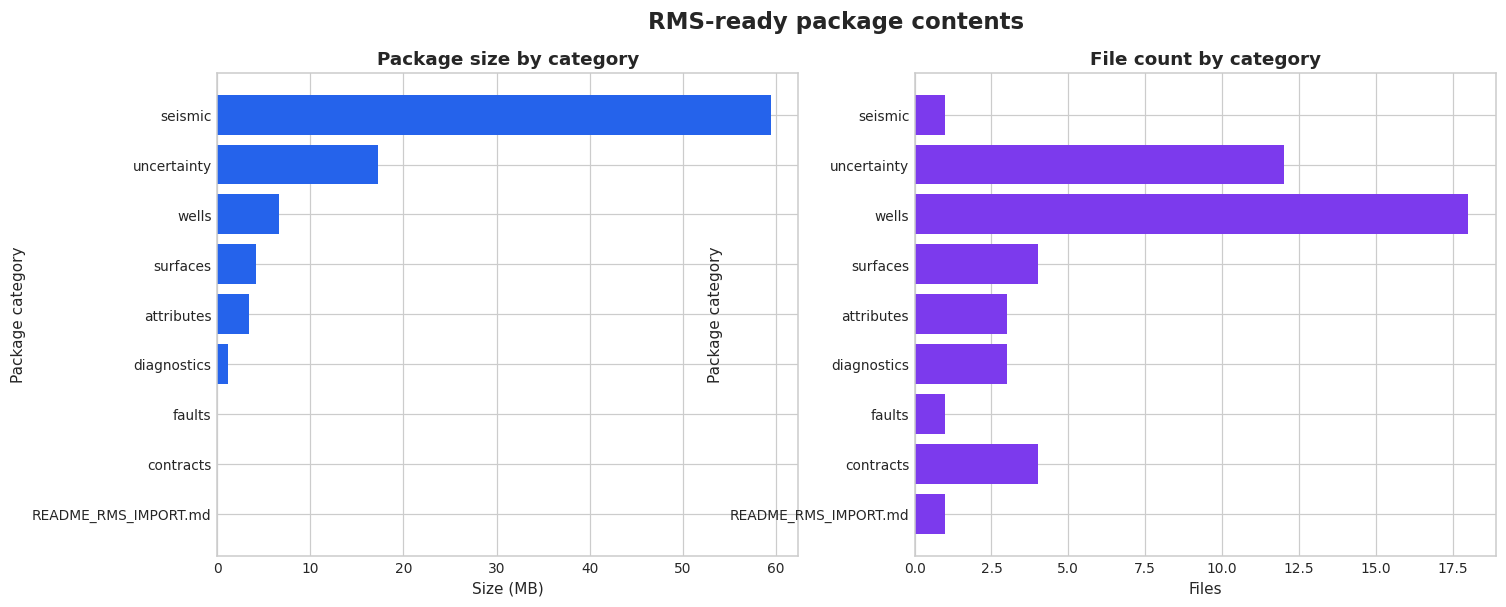

In [32]:
category_summary = package_inventory.copy()
category_summary["category"] = category_summary["path"].str.split("/").str[0]
category_summary = (
    category_summary.groupby("category", as_index=False)
    .agg(files=("path", "count"), megabytes=("size (MB)", "sum"))
    .sort_values("megabytes", ascending=True)
)

package_figure, package_axes = plt.subplots(1, 2, figsize=(15.0, 5.7))
package_axes[0].barh(
    category_summary["category"],
    category_summary["megabytes"],
    color=COLORS["processed"],
)
package_axes[0].set_title("Package size by category")
package_axes[0].set_xlabel("Size (MB)")
package_axes[0].set_ylabel("Package category")

package_axes[1].barh(
    category_summary["category"],
    category_summary["files"],
    color=COLORS["uncertainty"],
)
package_axes[1].set_title("File count by category")
package_axes[1].set_xlabel("Files")
package_axes[1].set_ylabel("Package category")

package_figure.suptitle(
    "RMS-ready package contents",
    fontsize=15,
    weight="bold",
)
save_figure(package_figure, "15_rms_package_inventory.png")
plt.show()

## 12. Independent round-trip validation

Export success is not assumed from the absence of an exception. The conditioned SEG-Y, interpreted
surfaces, fault polygons, RMS well, and LAS log are reopened with independent readers. Geometry,
counts, sampling, and numerical differences are checked. The manifest hashes are recalculated
from disk.

In [33]:
roundtrip_cube = xtgeo.cube_from_file(conditioned_segy_path)
roundtrip_top = xtgeo.surface_from_file(top_surface_path, fformat="irap_ascii")
roundtrip_base = xtgeo.surface_from_file(base_surface_path, fformat="irap_ascii")
roundtrip_faults = xtgeo.polygons_from_file(fault_output_path)
roundtrip_well = xtgeo.well_from_file(PACKAGE_DIRECTORY / "wells" / "OP_1.w")
roundtrip_las = lasio.read(PACKAGE_DIRECTORY / "wells" / "OP_1.las")

top_roundtrip_difference_m = float(
    np.ma.max(np.ma.abs(roundtrip_top.values - top_interpreted_surface.values))
)
base_roundtrip_difference_m = float(
    np.ma.max(np.ma.abs(roundtrip_base.values - base_interpreted_surface.values))
)

manifest_hashes_valid = True
for manifest_item in rms_import_manifest["files"]:
    file_path = PACKAGE_DIRECTORY / manifest_item["path"]
    manifest_hashes_valid = (
        manifest_hashes_valid
        and file_path.stat().st_size == manifest_item["bytes"]
        and sha256_file(file_path) == manifest_item["sha256"]
    )

roundtrip_table = pd.DataFrame(
    {
        "check": [
            "SEG-Y dimensions",
            "SEG-Y Z sampling",
            "top surface maximum difference",
            "base surface maximum difference",
            "fault point count",
            "RMS well row count",
            "LAS curve count",
            "manifest hashes",
        ],
        "result": [
            (
                f"{roundtrip_cube.ncol} × {roundtrip_cube.nrow} × "
                f"{roundtrip_cube.nlay}"
            ),
            f"{roundtrip_cube.zinc:.3f} m",
            f"{top_roundtrip_difference_m:.6f} m",
            f"{base_roundtrip_difference_m:.6f} m",
            str(len(roundtrip_faults.dataframe)),
            str(len(roundtrip_well.dataframe)),
            str(len(roundtrip_las.curves)),
            "PASS" if manifest_hashes_valid else "FAIL",
        ],
    }
)
display(roundtrip_table)

,check,result
0,SEG-Y dimensions,408 × 280 × 70
1,SEG-Y Z sampling,5.000 m
2,top surface maximum difference,0.000000 m
3,base surface maximum difference,0.000000 m
4,fault point count,754
5,RMS well row count,4866
6,LAS curve count,6
7,manifest hashes,PASS


## 13. What the licensed RMS worker must do

The generated `rms_worker_request.json` is deliberately declarative. It tells a governed worker
what to import and in which order, while keeping credentials, project paths, and proprietary API
details outside the public notebook.

The worker should:

1. verify the package manifest and project CRS/datum;
2. create new named seismic, surface, fault, and well objects;
3. stop for human review before committing the structural framework;
4. build the geological grid, zones, facies, and petrophysical properties in RMS;
5. exclude the rejected diagnostic porosity map;
6. export ROFF geometry/properties and an exact checksum manifest;
7. hand those artifacts to the downstream RMS → OPM Flow → ERT → NeqSim notebook.

The public notebook proves every calculation up to that boundary. It does not claim that a
licensed RMS run occurred.

In [34]:
approved_actions = pd.DataFrame(
    [
        {
            "order": action["order"],
            "operation": action["operation"],
            "human review gate": action.get("human_review_gate", False),
        }
        for action in rms_worker_request["actions"]
    ]
)
display(approved_actions)
print(json.dumps(rms_worker_request["excluded_from_approved_imports"], indent=2))

[
  {
    "path": "diagnostics/rejected_seismic_porosity_trend.fgr",
    "reason": "Leave-one-well-out validation did not pass the acceptance gate."
  }
]


,order,operation,human review gate
0,1,import_seismic_cube,False
1,2,import_horizon_surfaces,False
2,3,import_fault_polygons,False
3,4,import_wells_and_logs,False
4,5,import_secondary_attribute_maps,False
5,6,build_structural_and_geological_model,True
6,7,export_roff_handoff,False


## 14. Bridge to OPM Flow, ERT, and NeqSim

After RMS produces the ROFF handoff, continue with
[`rms_to_opm_flow_agent_ert.ipynb`](rms_to_opm_flow_agent_ert.ipynb). Together, the two notebooks
form this chain:

**field records → seismic processing → processed SEG-Y → wells/ties → horizons/faults →
RMS-ready package → licensed RMS geomodel → ROFF → blocking/property spreading → OPM Flow →
ERT ensembles → NeqSim PVT and facilities**

The seam between the notebooks is intentional. It makes the commercial-software boundary
visible, auditable, and replaceable by a governed RMS worker without pretending that Colab can
run RMS.

In [35]:
with zipfile.ZipFile(zip_path) as package_archive:
    zip_integrity_ok = package_archive.testzip() is None
    zip_members = set(package_archive.namelist())

validation_checks = {
    "all public input checksums passed": bool(input_inventory["SHA-256 verified"].all()),
    "SEG-Y trace count matches cube geometry": (
        segy_trace_count == seismic_cube.ncol * seismic_cube.nrow
    ),
    "SEG-Y samples match cube layers": segy_sample_count == seismic_cube.nlay,
    "cube vertical increment is 5 m": np.isclose(seismic_cube.zinc, 5.0),
    "active seismic traces exist": int(np.sum(active_trace_mask)) > 90000,
    "isolated amplitude outliers were detected": len(outlier_indices) > 0,
    "conditioned maximum amplitude is below threshold": (
        np.max(np.abs(conditioned_values)) <= outlier_limit
    ),
    "eight property-bearing wells were interpreted": len(well_summary) == 8,
    "all well-to-trace distances are below one trace spacing": (
        well_summary["trace distance (m)"].max()
        <= max(seismic_cube.xinc, seismic_cube.yinc)
    ),
    "top phase shift is finite": np.isfinite(top_phase_shift_m),
    "base phase shift is finite": np.isfinite(base_phase_shift_m),
    "top control count exceeds 50": int(np.sum(top_control_mask)) > 50,
    "base control count exceeds 50": int(np.sum(base_control_mask)) > 50,
    "top horizon RMSE is below 20 m": top_rmse_m < 20.0,
    "base horizon RMSE is below 20 m": base_rmse_m < 20.0,
    "interpreted gross thickness exceeds 10 m": (
        float(gross_thickness_surface.values.min()) > 10.0
    ),
    "faults have stronger discontinuity than background": fault_support_ratio > 1.2,
    "illustrative depth conversion RMSE is below 5 m": depth_conversion_rmse_m < 5.0,
    "six structural realizations were generated": (
        len(top_realization_surfaces) == number_of_realizations == 6
    ),
    "all structural GRVs are positive": bool(
        np.all(grv_table["GRV (million m3)"] > 0.0)
    ),
    "interval attributes contain finite values": bool(
        np.all(np.isfinite(rms_amplitude_surface.values.compressed()))
    ),
    "unsupported porosity trend was rejected": not porosity_model_accepted,
    "conditioned SEG-Y roundtrip dimensions match": (
        roundtrip_cube.dimensions == conditioned_cube.dimensions
    ),
    "top IRAP surface roundtrip is within 1 mm": top_roundtrip_difference_m < 0.001,
    "base IRAP surface roundtrip is within 1 mm": base_roundtrip_difference_m < 0.001,
    "fault polygon point count roundtrips": (
        len(roundtrip_faults.dataframe) == len(fault_polygons.dataframe)
    ),
    "RMS well retains reservoir logs": {
        "Poro",
        "Perm",
        "Facies",
        "Zonelog",
    }.issubset(roundtrip_well.dataframe.columns),
    "LAS export retains six curves": len(roundtrip_las.curves) == 6,
    "package manifest hashes pass": manifest_hashes_valid,
    "RMS package ZIP passes integrity test": zip_integrity_ok,
    "RMS package ZIP contains the import manifest": (
        "contracts/rms_import_manifest.json" in zip_members
    ),
    "RMS package ZIP contains conditioned SEG-Y": (
        "seismic/reek_depth_stack_qc.segy" in zip_members
    ),
    "all retained figures exist": all(path.is_file() for path in FIGURE_PATHS),
    "at least fifteen figures were retained": len(FIGURE_PATHS) >= 15,
}

validation_table = pd.DataFrame(
    {
        "validation check": list(validation_checks),
        "passed": list(validation_checks.values()),
    }
)
display(validation_table)
failed_checks = [
    name for name, passed in validation_checks.items() if not bool(passed)
]
if failed_checks:
    raise AssertionError(f"Validation failed: {failed_checks}")

result_summary = {
    "public_input_files": len(PUBLIC_INPUTS),
    "cube_dimensions": list(conditioned_cube.dimensions),
    "outlier_traces_repaired": len(outlier_indices),
    "property_wells": len(well_summary),
    "top_phase_shift_m": top_phase_shift_m,
    "base_phase_shift_m": base_phase_shift_m,
    "top_horizon_rmse_m": top_rmse_m,
    "base_horizon_rmse_m": base_rmse_m,
    "fault_support_ratio": fault_support_ratio,
    "depth_conversion_rmse_m": depth_conversion_rmse_m,
    "structural_realizations": number_of_realizations,
    "porosity_trend_accepted": porosity_model_accepted,
    "package_files": len(package_inventory),
    "package_zip_mb": zip_path.stat().st_size / 1.0e6,
    "figures": [path.name for path in FIGURE_PATHS],
    "checks_passed": int(sum(bool(value) for value in validation_checks.values())),
    "checks_total": len(validation_checks),
}
display(pd.Series(result_summary, name="result"))

,validation check,passed
0,all public input checksums passed,True
1,SEG-Y trace count matches cube geometry,True
2,SEG-Y samples match cube layers,True
3,cube vertical increment is 5 m,True
4,active seismic traces exist,True
5,isolated amplitude outliers were detected,True
6,conditioned maximum amplitude is below threshold,True
7,eight property-bearing wells were interpreted,True
8,all well-to-trace distances are below one trac...,True
9,top phase shift is finite,True


public_input_files                                                        13
cube_dimensions                                               [408, 280, 70]
outlier_traces_repaired                                                    6
property_wells                                                             8
top_phase_shift_m                                                       10.0
base_phase_shift_m                                                     -10.0
top_horizon_rmse_m                                                 14.243662
base_horizon_rmse_m                                                14.062305
fault_support_ratio                                                 2.160662
depth_conversion_rmse_m                                               1.1165
structural_realizations                                                    6
porosity_trend_accepted                                                False
package_files                                                             47

## Results and engineering interpretation

The notebook has now calculated, visualized, exported, and independently reopened the complete
public path from a simplified field-record calculation to an RMS-ready package. The horizon
metrics quantify what the sparse seeded tracker can and cannot recover. The fault-support ratio
provides independent seismic evidence for the supplied polygons. Structural residuals drive six
explicit uncertainty realizations and gross-rock-volume calculations.

The porosity acceptance gate is intentionally strict. Because the seismic attribute does not add
enough blind-well predictive skill, it remains a diagnostic rather than an approved RMS property
trend. This is the scientifically correct outcome for the data available.

The next non-public step is a reviewed, licensed RMS run that builds the geological grid and
exports ROFF files. Only after that step should the downstream OPM Flow, ERT, and NeqSim workflow
be treated as the continuation of this exact model realization.

## Limitations

- The acquisition example demonstrates CMP moveout and stacking only; it is not field processing.
- The Reek seismic, wells, and references are synthetic public test fixtures, not measured field
  data or a reserves basis.
- Sparse controls are sampled from the public reference to create a deterministic benchmark.
- The public cube is already in depth; the checkshot calculation is illustrative and kept outside
  the approved Reek import actions.
- The fault polygon is interpreter-supplied; the discontinuity calculation supports but does not
  generate it.
- The structural realizations do not model discrete fault scenarios or a calibrated velocity
  covariance.
- Eight property wells are insufficient for a decision-grade seismic-to-porosity relationship.
- No authoritative CRS/EPSG identifier is claimed for the public fixture.
- RMS is not executed in Colab. The agent contract requires a licensed worker and human approval.
- Nothing in this notebook constitutes certified interpretation, reservoir characterization,
  reserves classification, or design assurance.

## References and formats

- [SEG Technical Standards](https://seg.org/publications/seg-technical-standards/) — official
  SEG-Y standards and open examples.
- [XTGeo data model and supported formats](https://xtgeo.readthedocs.io/en/stable/datamodels.html)
  — SEG-Y cubes, IRAP/RMS surfaces, wells, polygons, ROFF, and Roxar interfaces.
- [XTGeo examples](https://xtgeo.readthedocs.io/en/stable/tutorial/examples.html) — cube slicing,
  interval attributes, and RMS-format exports.
- [equinor/xtgeo-testdata](https://github.com/equinor/xtgeo-testdata) — pinned public synthetic
  Reek fixtures and LGPL v3.0 licence.
- [segyio](https://github.com/equinor/segyio) — SEG-Y inspection and I/O.

## Suggested exercises

1. Change the control spacing from 32 to 16 and 48 traces. Plot RMSE against interpreter effort.
2. Vary search-window width and jump penalty, but select them only on a training subset of lines.
3. Replace the simple gradient proxy with local semblance or structure-oriented coherence.
4. Construct separate picking, mistie, velocity, and fault-position uncertainty components.
5. Add a public time-migrated cube and use real checkshots for depth conversion.
6. Test nonlinear and facies-conditioned seismic-property relationships with nested cross-validation.
7. Extend the RMS worker contract with project-specific CRS, naming, realization, and approval rules.
8. Run the downstream RMS → OPM Flow → ERT → NeqSim notebook on the reviewed ROFF export.